[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/reinhart-group/generative-copolymer-workshop/blob/main/day2/05_mapping.ipynb)

# Day 2, async: mapping to the master dataset

Today's topics:
* Pooling per-view fingerprints into one vector per sequence, and what the spread tells you
* Placing a genuinely new sequence on the **persisted, deployed map**, never re-fitting it
* Fit-once, transform-forever: why the map notebooks 06-09 use is frozen the moment NB04 built it
* Who your latent neighbors are, and how notebook 06 gets its `(sequence, z)` training table

*Where are we in the pipeline?*

Notebook 04 built and validated a 2-D PCA map $g: \mathbb{R}^{1280} \to \mathbb{R}^2$, fit on 64 pre-simulated sequences and persisted to `data/master64/pca.joblib`.
Here you take a sequence that was not one of those 64, push it through the frozen $g$, and see where it lands relative to the rest of the design space.

*What's the goal today?*

Day 1 gave you a CNN feature vector for whatever sequence(s) you simulated.
Notebook 04 showed that compressing 1280-d fingerprints down to 2 PCA dimensions produces a map with real morphological structure, but it only demonstrated that on the 64 sequences the map was fit on.
A deployed map is only useful if it can also place sequences it has never seen.
Keep the original design problem in view while we do this bookkeeping.
Every point on this map is one polymer sequence's self-assembled structure, and it's this shared, deployed map that lets Day 3 search for a sequence that lands on a target morphology.

At length 10 the whole design space is small enough to enumerate exactly: $2^{10} = 1024$ binary strings.
Collapsing reversal-symmetric duplicates (a chain read head-to-tail is the same physical object as its reverse) leaves **528 canonical sequences**, every one already simulated and featurized in `data/exhaustive10/`.

That total isn't simply half of 1024.
32 of the 1024 strings are palindromes, reading the same forwards and backward, and a palindrome has no distinct reverse-partner to pair off with during the collapse, so it survives as its own canonical sequence.
496 reverse-pairs collapse to 496, plus 32 self-paired palindromes, giving $496 + 32 = 528$.

The deployed map, by contrast, was fit on a random subsample of 64 sequences, a deliberately small, deployment-honest choice.
A real cohort will only ever have a handful of freshly-simulated sequences to place, not the whole library.

So of the 528 canonical sequences, 464 are "new" relative to the fitted map, in exactly the sense a student's freshly-simulated sequence would be.
This notebook picks one of those 464, transforms it through the frozen PCA, and reads off where it lands: the deployment scenario in miniature.

This is a simplified, single-stage stand-in for the two-stage local-to-global embedding pipeline of Statt, Kleeblatt and Reinhart (*Soft Matter* 2021), who originally simulated only about 1,000-2,000 of their much larger design space (roughly 1.6-3%) with MD: the same "small fitted sample, big design space" situation, at a different chain length.

This notebook simulates a live trajectory later on, in a section below.
It needs the same conda-forge HOOMD stack as Day 1's notebooks 01/02, installed first since it restarts the runtime.

In [ ]:
#@title  ⚙️  Step 1 of 2 — install conda (causes a restart; that's normal). { display-mode: "form" }
# Guarded so this cell is safe to re-run. Once condacolab has converted the runtime, the
# Python it installs (3.12) has no `distutils`, which condacolab itself imports -- so a
# student who hits "Runtime -> Restart session" and re-runs from the top would otherwise get
# a baffling `ModuleNotFoundError: No module named 'distutils'` instead of a no-op.
import os
if os.path.exists('/usr/local/bin/conda'):
    print('✅ conda is already installed on this runtime — skipping (no restart needed).')
else:
    !pip install -q condacolab
    import condacolab
    condacolab.install()   # this restarts the kernel; the notebook continues from Step 2

In [ ]:
#@title  ⚙️  Step 2 of 2 — install the simulation + drawing packages (~2 min). { display-mode: "form" }
# NOTE TO INSTRUCTORS: do NOT put `%%capture` (or any %% cell magic) below this line.
# A cell magic must be the FIRST line of the cell, and line 1 here is the #@title form
# header — so `%%capture` on line 2 is parsed as a *line* magic, raises UsageError, and
# silently skips the entire install. We shipped exactly that bug once; the conda output
# stays visible on purpose, because a solver failure here is what you need to see.
!conda install -y -q python=3.12 scipy gsd "hoomd=*=cpu*" freud fresnel pillow
!pip install -q plotly "nbformat>=4.2.0"   # nbformat: lets plotly emit its mimetype bundle (VS Code/JupyterLab)

# Python caches the contents of every sys.path directory at interpreter start, so packages
# conda just created are invisible to `import` until those caches are dropped. Without this
# the verification below fails with ModuleNotFoundError even though the install succeeded.
import importlib
importlib.invalidate_caches()

import hoomd, gsd, freud, fresnel
print(f'✅ simulation stack ready — HOOMD-blue {hoomd.version.version}, freud {freud.__version__}')

In [4]:
#@title  ⚙️  Setup — build the workshop workspace (Colab). { display-mode: "form" }
# The "Open in Colab" badge loads ONLY this .ipynb into a bare VM at /content, so the
# directory layout this notebook reads by relative path -- ../data (derived tables) and
# ../models (the trained surrogate) -- does not exist yet. We do NOT clone the repo: every
# data and model artifact is published in the Zenodo bundle (concept DOI 10.5281/zenodo.21382941,
# which always resolves to the latest version),
# which is public and sha256-verified, and the helper code is spliced into this notebook.
# So this cell just creates the workspace and steps into the day directory; the
# `ensure_bundle(...)` calls further down fetch the actual data into ../data on first use.
#
# Idempotent, and a no-op if you are already running from a repo checkout (instructors).
import os, sys

WORKSPACE = os.environ.get('CDSE_WORKSPACE', '/content/cdse-workshop')
DAY_DIR = 'day2'

if os.path.isdir('../data') and os.path.isdir('../campaign'):
    print('✅ already inside a workshop checkout — using its data/ and models/ directly')
else:
    for sub in ('data', 'models', DAY_DIR):
        os.makedirs(os.path.join(WORKSPACE, sub), exist_ok=True)
    os.chdir(os.path.join(WORKSPACE, DAY_DIR))
    print(f'✅ workspace ready — cwd={os.getcwd()}')
    print('   ../data and ../models will be filled from Zenodo by the ensure_bundle() calls below.')

✅ already inside a workshop checkout — using its data/ and models/ directly


## Where this comes from

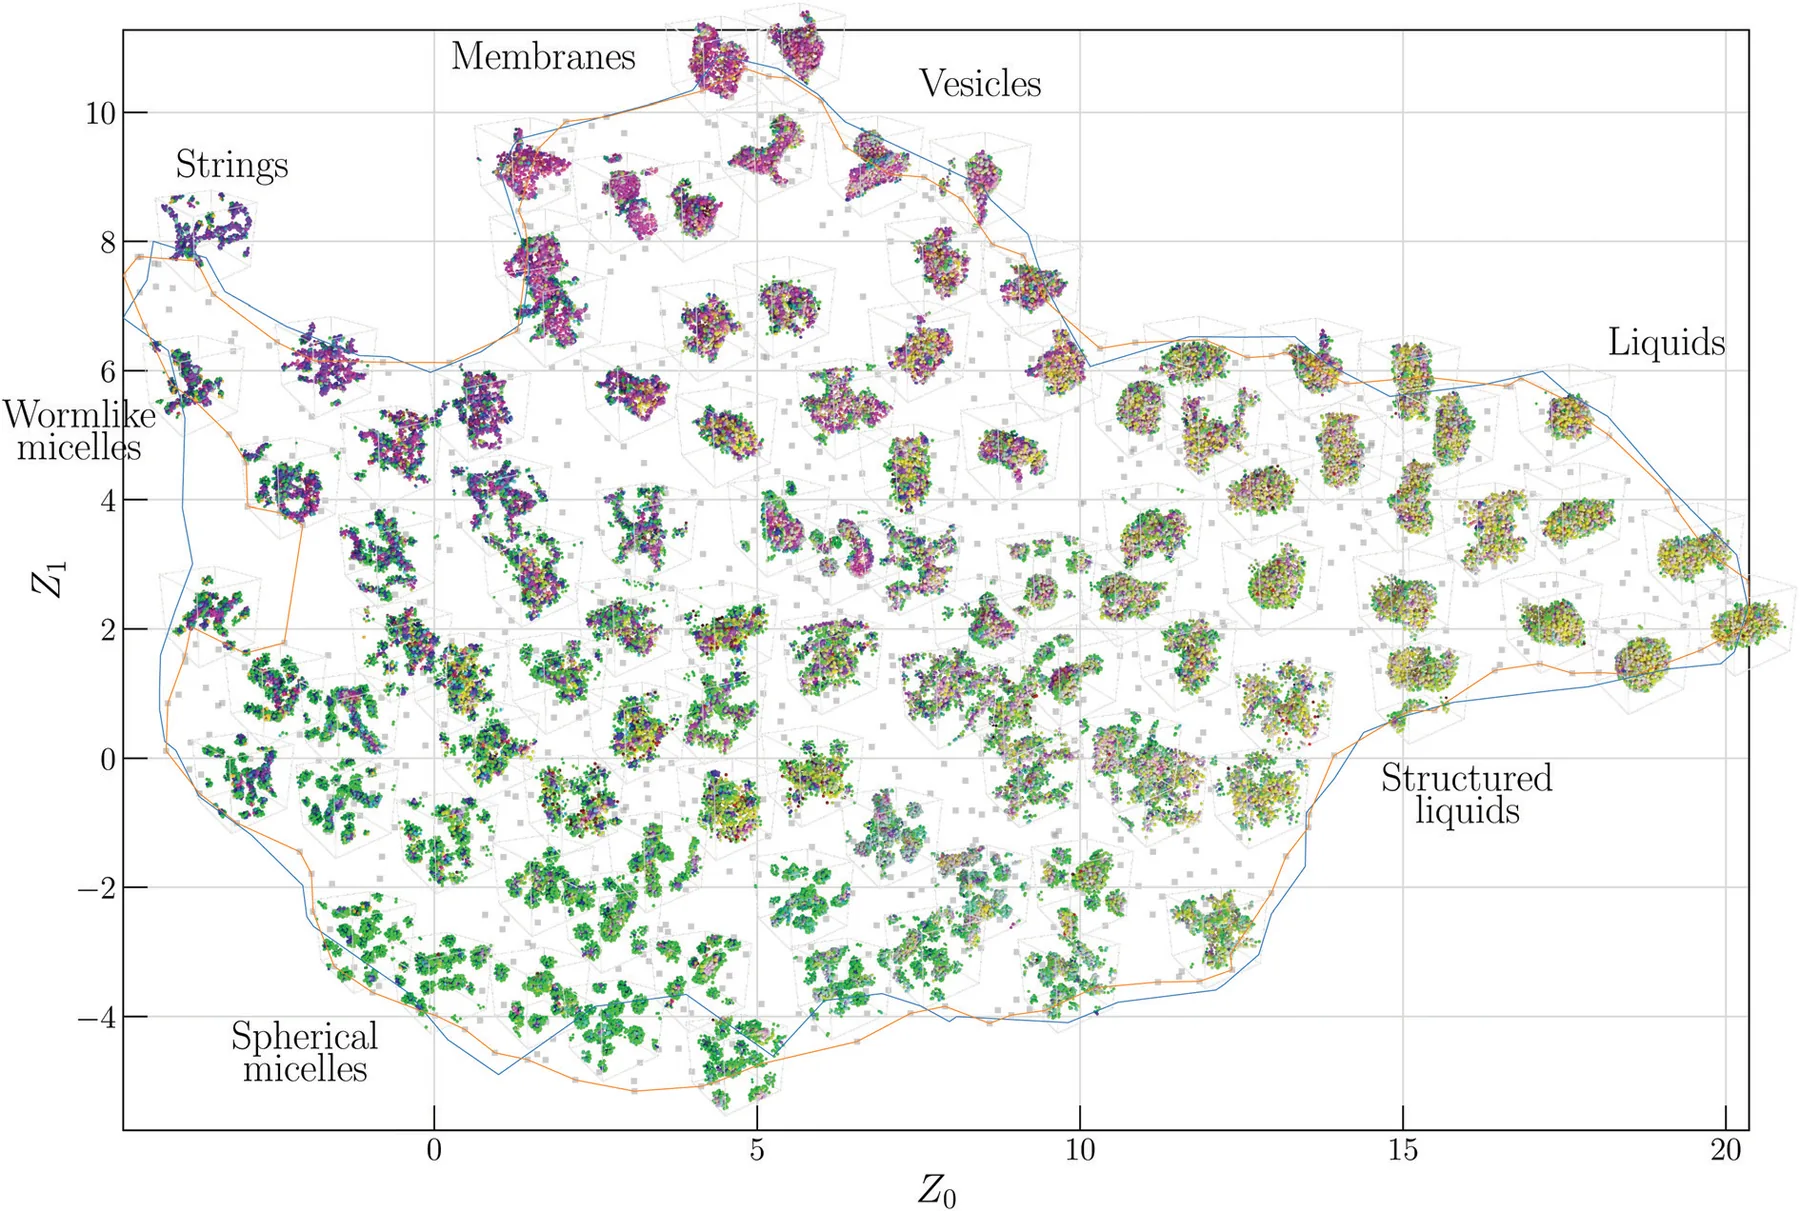

*Fig. 4, Statt, Kleeblatt and Reinhart, Soft Matter **17**, 7697 (2021). [doi.org/10.1039/d1sm01012c](https://doi.org/10.1039/d1sm01012c)*

This UMAP atlas organizes 1,022 self-assembled structures without morphology labels.
Strings, membranes, vesicles and liquids occupy distinct regions, with mixed structures between them.

Your frozen PCA map plays the same role, but it is not the same fitted object.
You place one unseen sequence, inspect its neighbors, and ask whether location still carries physical meaning.

The workshop uses a smaller sample and different features, so don't compare axes directly.
Compare the principle: a useful map makes nearby structures look alike.

In [5]:
"""KDE density images + EfficientNet features, adapted to the A/B bead system.

Channels: 'A' (type-0 density), 'B' (type-1 density), 'all' (both).
Views: xy, xz, yz. Mirrors day2/workshop_img_processing.ipynb naming so the
Day 2 loaders find the files: '{channel}_{view}_cv2_kde_sigma_{sigma}_size_{size}.png'.
"""
import os

import numpy as np
from scipy.ndimage import gaussian_filter
from PIL import Image

_VIEWS = {"xy": (0, 1), "xz": (0, 2), "yz": (1, 2)}
_CHANNELS = {"A": 0, "B": 1, "all": None}


def _minimum_image(pos, box):
    """Wrap positions into [-L/2, L/2) via the minimum-image convention.

    GSD frames already store *wrapped* positions, so for freshly-loaded
    frames this is a no-op; it also makes the function safe to call on
    positions that were unwrapped upstream for some other purpose.
    """
    return pos - box * np.round(pos / box)


def _circular_center(pos, box):
    """Center a periodic point cloud using a circular (angular) mean per axis.

    A wrapped Cartesian cloud on a torus has no well-defined arithmetic
    mean: a cloud straddling the box edge averages to the middle of the box
    instead of to its true centroid. Mapping each axis to an angle,
    averaging on the unit circle, and mapping back gives a center that is
    invariant to which periodic image each bead happens to be stored in.
    """
    theta = 2 * np.pi * (pos / box)
    ang = np.arctan2(np.sin(theta).mean(axis=0), np.cos(theta).mean(axis=0))
    com = ang / (2 * np.pi) * box
    return _minimum_image(pos - com, box)


def _density_hist(pts2d, box2d, img_size):
    """Raw (unsmoothed) 2-D histogram over the unchanged [-L/2, L/2] range.

    Split out from `_kde_image` so tests can assert the bin counts sum to
    the input point count (i.e. zero points fell outside the range) using
    the renderer's own histogramming code, not a reimplementation of it.
    """
    H, _, _ = np.histogram2d(
        pts2d[:, 0], pts2d[:, 1], bins=img_size,
        range=[[-box2d[0] / 2, box2d[0] / 2], [-box2d[1] / 2, box2d[1] / 2]])
    return H


def _kde_image(pts2d, box2d, img_size, kde_sigma):
    H = _density_hist(pts2d, box2d, img_size)
    # Periodic boundary conditions: smooth around the box edges instead of
    # letting density leak off (and vanish past) the edge of the image.
    H = gaussian_filter(H, sigma=kde_sigma, mode="wrap")
    if H.max() > 0:
        H = H / H.max()
    return (H * 255).astype(np.uint8)


def render_kde_images(traj, out_dir, kde_sigma=2.0, img_size=224, center=False, frame_idx=-1):
    """Render KDE density images from one frame of a trajectory (default: final frame).

    Density in a periodic box is a field on the torus, so this renders it as
    one: positions are taken via the minimum-image convention (never
    unwrap-then-crop, which silently drops any bead that lands in a
    different periodic image than the arbitrary global mean after
    unwrapping), histogrammed over the unchanged [-L/2, L/2] range so
    nothing falls outside it, and smoothed with periodic ("wrap") boundary
    conditions.

    frame_idx=-1 (default): the final frame, matching every existing call
        site. Pass a different index (e.g. 0) to render an earlier frame --
        used by 05_mapping's within-trajectory z(t) demo.

    center=False (default, "floor-only"): no re-centering beyond the
        minimum-image wrap.
    center=True ("floor+centering"): additionally re-centers the aggregate
        with a periodic (circular-mean) center, so the same morphology
        renders identically regardless of its absolute position in the box.
        For a dispersed configuration the resultant vector is near-zero, so
        the center is arbitrary but harmless; for lamellar/stripe
        morphologies the phase can be ambiguous.
    """
    os.makedirs(out_dir, exist_ok=True)
    frame = traj.frames[frame_idx]
    box = frame["box"]
    pos = _minimum_image(frame["position"], box)
    if center:
        pos = _circular_center(pos, box)
    tid = frame["typeid"]
    paths = []
    for ch, tval in _CHANNELS.items():
        sel = np.ones(len(pos), bool) if tval is None else (tid == tval)
        for view, (a, b) in _VIEWS.items():
            img = _kde_image(pos[sel][:, [a, b]], box[[a, b]], img_size, kde_sigma)
            fname = f"{ch}_{view}_cv2_kde_sigma_{kde_sigma}_size_{img_size}.png"
            path = os.path.join(out_dir, fname)
            Image.fromarray(img).save(path)
            paths.append(path)
    return paths


def extract_features(image_paths, model_name="efficientnet_b0", seq=None):
    """Extract EfficientNet penultimate-layer features for a set of KDE images.

    Returns a DataFrame with columns 'Beads', 'View', 'Feature' (one row per
    image path). If `seq` is given, an additional 'Sequence' column is
    inserted as the first column, stamped with `seq` for every row.
    """
    import pandas as pd
    import torch
    from torchvision import models, transforms

    weights = models.EfficientNet_B0_Weights.DEFAULT
    net = models.efficientnet_b0(weights=weights)
    net.classifier = torch.nn.Identity()  # 1280-dim penultimate features
    net.eval()
    tf = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    rows = []
    with torch.no_grad():
        for path in image_paths:
            base = os.path.basename(path)
            channel, view = base.split("_")[0], base.split("_")[1]
            img = Image.open(path)
            x = tf(img).unsqueeze(0)
            feat = net(x).squeeze(0).numpy()
            rows.append({"Beads": str([channel]), "View": view, "Feature": feat.tolist()})
    df = pd.DataFrame(rows)
    if seq is not None:
        df.insert(0, "Sequence", seq)
    return df


def slice_mask(pos, box, axis="y", delta_frac=0.10):
    """Boolean mask selecting beads within a thin slab around the box center along `axis`.

    `pos` must already be minimum-image wrapped (see `_minimum_image`) -- a geometric slice
    through a periodic box is only meaningful on wrapped coordinates, never on
    unwrapped/drifted ones. Returns (mask, delta): the boolean mask and the half-thickness
    (in the same units as `box`) actually used.
    """
    axis_idx = {"x": 0, "y": 1, "z": 2}[axis]
    delta = delta_frac * box[axis_idx] / 2
    return np.abs(pos[:, axis_idx]) <= delta, delta

In [ ]:
# If running on Colab, uncomment and run this cell first, then restart the runtime:
# !pip install "scikit-learn>=1.3,<2"

# To verify installed versions after installing:
# import sklearn; print(sklearn.__version__)

*What are we using?*

* `numpy`: numerical arrays
* `pandas`: tabular data
* `matplotlib`: plots
* `joblib`: loading the persisted PCA object (`pca.joblib`)
* `torch`, `torchvision`, `PIL`: re-featurizing one new sequence with the exact pipeline the deployed PCA was fit on (pre-installed on Colab, same pipeline as Day 1's notebook 03)
* `scikit-learn` (`NearestNeighbors`): latent-neighbor lookup
* `os`, `ast`: file discovery and string parsing

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os, ast
import joblib

In [8]:
#@title  ⚙️  data_bootstrap — verify data/master64 & data/exhaustive10 artifacts are present. You can ignore this cell. { display-mode: "form" }
#
# A fresh checkout only ships the small derived tables in data/master64/ (tracked in git,
# see data/master64/README.md) -- the large binaries (pca.joblib, atlas*.png, _images/) and
# the full exhaustive10 library are regenerated or fetched separately and are NOT guaranteed
# to be present. Rather than let a missing file surface as a cryptic pandas/joblib traceback
# many cells later, this module checks up front and fails with an actionable message.
#
# This is deliberately a *data*-layer check, not a model one: models/gru_bundle.joblib has
# its own, stricter provenance binding (sha256 of pca.joblib + sequence_z_targets.csv recorded
# inside the bundle, checked at load time -- see notebook 06, "Provenance binding, not just a
# file-exists cache"). That check catches "this trained model doesn't match today's data" and
# is not duplicated here. This module only answers the earlier question: are the required data
# files even on disk, and do the git-tracked ones match what's checked in (data/master64/checksums.json)?

import hashlib
import json
import os
import shutil
import tarfile
import urllib.request

import numpy as np
import pandas as pd


def sha256_of_file(path, chunk_size=1 << 20):
    """Hash a file's bytes. Same convention notebook 06 uses to bind gru_bundle.joblib
    to the pca.joblib / sequence_z_targets.csv it was trained against."""
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            h.update(chunk)
    return h.hexdigest()


def require_data_artifacts(base_dir, filenames, checksums_path=None, regen_hint=''):
    """Verify each of `filenames` exists under `base_dir`, and -- if `checksums_path` points
    at a JSON {filename: sha256} manifest that has an entry for it -- that its sha256 matches.

    Call this once, right after the relevant `*_DIR` is set, before any of `filenames` is
    read. Raises RuntimeError with every missing/mismatched file listed together (not just
    the first one hit) and a regeneration hint, instead of letting the notebook die on
    whichever read happens to come first.
    """
    checksums = {}
    if checksums_path and os.path.exists(checksums_path):
        with open(checksums_path) as f:
            checksums = json.load(f)

    missing, mismatched = [], []
    for name in filenames:
        path = os.path.join(base_dir, name)
        if not os.path.exists(path):
            missing.append(path)
            continue
        expected = checksums.get(name)
        if expected is not None:
            actual = sha256_of_file(path)
            if actual != expected:
                mismatched.append((path, expected, actual))

    if not missing and not mismatched:
        return

    parts = []
    if missing:
        listed = '\n  '.join(missing)
        parts.append(f'Missing required data artifact(s):\n  {listed}')
    if mismatched:
        listed = '\n  '.join(
            f'{p}\n    expected sha256 {exp[:12]}…, found {act[:12]}… '
            f'(local file does not match data/master64/checksums.json)'
            for p, exp, act in mismatched
        )
        parts.append(f'Data artifact(s) present but do NOT match the checked-in checksums:\n  {listed}')
    if regen_hint:
        parts.append(regen_hint)
    raise RuntimeError('\n\n'.join(parts))


# ── exhaustive10 feature loaders (.npz, not .csv+ast.literal_eval) ─────────────
#
# `data/exhaustive10/master_pooled_features_corrected.npz` and
# `.../img_feats_efficientnet_b0_corrected_cv2_kde_sigma_2.0_size_224.npz` are the
# binary float32 replacements for two CSVs that used to store each 1280-d feature
# vector as a stringified Python list (slow to parse, ~5.9x larger on disk -- see
# campaign/persist_ex_pooled_features.py, which still writes both the .csv and the
# .npz). These two loaders parse the .npz and hand back a DataFrame with the exact
# same columns/dtypes the old CSV+ast.literal_eval loaders produced, so downstream
# code that consumes the DataFrame does not need to change.
#
# npz schema (written by campaign/persist_ex_pooled_features.py's converter):
#   master_pooled_features_corrected.npz
#     sequences: (528,)  zero-padded 10-char sequence strings
#     feats:     (528, 1280) float32 -- row i is the pooled fingerprint for sequences[i]
#   img_feats_efficientnet_b0_corrected_cv2_kde_sigma_2.0_size_224.npz
#     sequences: (4752,), beads: (4752,) e.g. "['A']", views: (4752,) e.g. 'xy'
#     feats:     (4752, 1280) float32

def load_pooled_feature_npz(path, dtype=np.float32):
    """Load a pooled-feature .npz (sequences, feats) into a DataFrame with columns
    Sequence, Feature -- Feature is a per-row 1-D array of `dtype`, matching the shape
    the old `load_feature_csv(pooled_csv_path)` produced."""
    d = np.load(path)
    feats = d['feats'].astype(dtype)
    return pd.DataFrame({
        'Sequence': d['sequences'],
        'Feature': list(feats),
    })


def load_perview_feature_npz(path, dtype=np.float32):
    """Load a per-view-feature .npz (sequences, beads, views, feats) into a DataFrame
    with columns Sequence, Beads, View, Feature -- matching the old per-view CSV's
    schema (Beads stays a Python-list-repr string, e.g. "['A']", exactly as
    `beads_match` expects)."""
    d = np.load(path)
    feats = d['feats'].astype(dtype)
    return pd.DataFrame({
        'Sequence': d['sequences'],
        'Beads': d['beads'],
        'View': d['views'],
        'Feature': list(feats),
    })


# ── Bundle fetch shim (data/_bundles/*.tar.gz) ──────────────────────────────
#
# `data/_bundles/` holds gzip-tar archives packaging the subset of `data/` a
# fresh checkout doesn't ship (large binaries: images, GSDs, the exhaustive10
# library). Each archive's relative paths match their layout under `data/`
# exactly (e.g. `master64/pca.joblib`, `exhaustive10/_images/<seq>/*.webp`), so
# extracting one directly into `data_dir` reproduces the paths every notebook
# already expects -- no notebook-side path changes needed once a bundle is
# fetched. See `data/_bundles/manifest.json` for the authoritative sha256/size
# of every archive; this module's `ensure_bundle` reads that same file.
#
# Hosted on Zenodo, concept DOI 10.5281/zenodo.21382941, which always resolves to the
# latest version. ZENODO_RECORD above pins a specific version record on purpose, so a
# checkout keeps fetching the exact archives it was tested against: currently v2
# (record 21856114), which adds the random-walk-init arm to v1's (21382942) lattice-init
# data. Zenodo carries every prior version's files forward, so the v1 archive names keep
# resolving against the newer record.
# Wired up and live: within Day 2, notebooks 04 and 05 call `ensure_bundle('core')`
# before the cells that read the large binaries (06 needs none). Calling it with an
# unknown bundle name raises a clear, actionable RuntimeError rather than failing
# confusingly deep in a download.
#
# Kept identical to day1/day3's copies of this shim (same URLs) -- duplicated per-day
# rather than cross-imported, matching this repo's existing convention of a
# self-contained data_bootstrap.py per day. Only the day-specific loaders above and
# day3's `reconcile_bundle_models()` differ between the three copies.

ZENODO_RECORD = 'https://zenodo.org/api/records/21856114/files'

BUNDLE_URLS = {
    'core': f'{ZENODO_RECORD}/core.tar.gz/content',
    'full_images': f'{ZENODO_RECORD}/full_images.tar.gz/content',
    'gsd_shard_01': f'{ZENODO_RECORD}/gsd_shard_01.tar.gz/content',
    'gsd_shard_02': f'{ZENODO_RECORD}/gsd_shard_02.tar.gz/content',
    'gsd_shard_03': f'{ZENODO_RECORD}/gsd_shard_03.tar.gz/content',
    'gsd_shard_04': f'{ZENODO_RECORD}/gsd_shard_04.tar.gz/content',
    'gsd_shard_05': f'{ZENODO_RECORD}/gsd_shard_05.tar.gz/content',
    'gsd_shard_06': f'{ZENODO_RECORD}/gsd_shard_06.tar.gz/content',
    'gsd_shard_07': f'{ZENODO_RECORD}/gsd_shard_07.tar.gz/content',
    'gsd_shard_08': f'{ZENODO_RECORD}/gsd_shard_08.tar.gz/content',
    'gsd_shard_09': f'{ZENODO_RECORD}/gsd_shard_09.tar.gz/content',
    'gsd_shard_10': f'{ZENODO_RECORD}/gsd_shard_10.tar.gz/content',
    'gsd_shard_11': f'{ZENODO_RECORD}/gsd_shard_11.tar.gz/content',
    'gsd_shard_12': f'{ZENODO_RECORD}/gsd_shard_12.tar.gz/content',
    'gsd_shard_13': f'{ZENODO_RECORD}/gsd_shard_13.tar.gz/content',
    'gsd_shard_14': f'{ZENODO_RECORD}/gsd_shard_14.tar.gz/content',
    'gsd_shard_15': f'{ZENODO_RECORD}/gsd_shard_15.tar.gz/content',
    'gsd_shard_16': f'{ZENODO_RECORD}/gsd_shard_16.tar.gz/content',
    'rwinit_core': f'{ZENODO_RECORD}/rwinit_core.tar.gz/content',
    'rwinit_gsd_shard_01': f'{ZENODO_RECORD}/rwinit_gsd_shard_01.tar.gz/content',
    'rwinit_gsd_shard_02': f'{ZENODO_RECORD}/rwinit_gsd_shard_02.tar.gz/content',
    'rwinit_gsd_shard_03': f'{ZENODO_RECORD}/rwinit_gsd_shard_03.tar.gz/content',
    'rwinit_gsd_shard_04': f'{ZENODO_RECORD}/rwinit_gsd_shard_04.tar.gz/content',
    'rwinit_gsd_shard_05': f'{ZENODO_RECORD}/rwinit_gsd_shard_05.tar.gz/content',
    'rwinit_gsd_shard_06': f'{ZENODO_RECORD}/rwinit_gsd_shard_06.tar.gz/content',
    'rwinit_gsd_shard_07': f'{ZENODO_RECORD}/rwinit_gsd_shard_07.tar.gz/content',
    'rwinit_gsd_shard_08': f'{ZENODO_RECORD}/rwinit_gsd_shard_08.tar.gz/content',
    'rwinit_gsd_shard_09': f'{ZENODO_RECORD}/rwinit_gsd_shard_09.tar.gz/content',
    'rwinit_gsd_shard_10': f'{ZENODO_RECORD}/rwinit_gsd_shard_10.tar.gz/content',
    'rwinit_gsd_shard_11': f'{ZENODO_RECORD}/rwinit_gsd_shard_11.tar.gz/content',
    'rwinit_gsd_shard_12': f'{ZENODO_RECORD}/rwinit_gsd_shard_12.tar.gz/content',
    'rwinit_gsd_shard_13': f'{ZENODO_RECORD}/rwinit_gsd_shard_13.tar.gz/content',
    'rwinit_gsd_shard_14': f'{ZENODO_RECORD}/rwinit_gsd_shard_14.tar.gz/content',
    'rwinit_gsd_shard_15': f'{ZENODO_RECORD}/rwinit_gsd_shard_15.tar.gz/content',
    'rwinit_gsd_shard_16': f'{ZENODO_RECORD}/rwinit_gsd_shard_16.tar.gz/content',
    'rwinit_images': f'{ZENODO_RECORD}/rwinit_images.tar.gz/content',
}


# Embedded copy of data/_bundles/manifest.json (sha256 + size only -- the two fields
# ensure_bundle verifies). The manifest normally ships in the repo, but a Colab student
# opens a bare .ipynb with no repo around it, so a repo-only manifest would make every
# ensure_bundle() call fail before it ever reached Zenodo. The on-disk file still wins
# when present (instructors regenerating bundles); this is the fallback.
EMBEDDED_MANIFEST = {
    "core.tar.gz": {
        "sha256": "aa8e566e323d83a3cf5bd9f8d66af97597176bfa556497536a2313d9257a86e8",
        "size_bytes": 75795762
    },
    "full_images.tar.gz": {
        "sha256": "f5a3be425507b54446b6b8b432432e612637a26105cacd94ba04f46f9fcd9f98",
        "size_bytes": 85260688
    },
    "gsd_shard_01.tar.gz": {
        "sha256": "5ffe93ba71d42eed5abeedcc6e4dd9e0bc8d160e3d2f134cea06285b9781d590",
        "size_bytes": 54428843
    },
    "gsd_shard_02.tar.gz": {
        "sha256": "541573a1d8176f89f4f838698bee261a24818c93967b0c969e8d295ba87805eb",
        "size_bytes": 54515060
    },
    "gsd_shard_03.tar.gz": {
        "sha256": "5fd7ed9efce62468b73e633b3dd56de13ca5d5e83c87222b5d0f30eab3cd874d",
        "size_bytes": 54500993
    },
    "gsd_shard_04.tar.gz": {
        "sha256": "7c2b102d648d918bb5f702137c925533c32c22070d5a20075b536f795251524c",
        "size_bytes": 54501617
    },
    "gsd_shard_05.tar.gz": {
        "sha256": "f8da9b7c5e515e5a61b6b91d390a65a95b85aab48a6b31c6a2f5bb786306e1ee",
        "size_bytes": 54486771
    },
    "gsd_shard_06.tar.gz": {
        "sha256": "40d94a51cf1c4e59e06998e438b40a67ee52f7447e4e8089e6c1ba3efe707e92",
        "size_bytes": 54503309
    },
    "gsd_shard_07.tar.gz": {
        "sha256": "3a1a633d093e8df54062868bca408b2ea81d3121b6e18e151fabd620c9908227",
        "size_bytes": 54545175
    },
    "gsd_shard_08.tar.gz": {
        "sha256": "6edd4e9b39081c82847da3e8f5c048ba07b774513514bb293d8fc43c5f59fe5c",
        "size_bytes": 54553660
    },
    "gsd_shard_09.tar.gz": {
        "sha256": "ddebef1f8420db4e1646013640450f06c50883cc8220e6fe47847dbc816bab48",
        "size_bytes": 54529750
    },
    "gsd_shard_10.tar.gz": {
        "sha256": "8f92a0c7261217e282f16370b1483ab72c7627d452369a302d4a1cb553fd2101",
        "size_bytes": 54576422
    },
    "gsd_shard_11.tar.gz": {
        "sha256": "b4f713683ce4c9a9c7338a973162c33e26fae4abd3198ce51a232d41ab7d8213",
        "size_bytes": 54614646
    },
    "gsd_shard_12.tar.gz": {
        "sha256": "c6d9199bb584dec3dab80518ce52e591d90dcbd55d4565a17bfd899cec1cde90",
        "size_bytes": 54558926
    },
    "gsd_shard_13.tar.gz": {
        "sha256": "e40332193347a5532fc560189608b46617fc277333be14ae6a1a73b4b619ea27",
        "size_bytes": 54515392
    },
    "gsd_shard_14.tar.gz": {
        "sha256": "cd88ff742f800ba576088cb680d0d61dd7c9c63090a77c25deeddf54d728f748",
        "size_bytes": 54556976
    },
    "gsd_shard_15.tar.gz": {
        "sha256": "d4eea2c8040774d777ac384b55c5a8e473e413619c8b799690121986dcce0c61",
        "size_bytes": 54553791
    },
    "gsd_shard_16.tar.gz": {
        "sha256": "403bf562e8325f34d4b04dff699d3cc35a9b4e7dda231e01a5fdb836a9b788d1",
        "size_bytes": 54546362
    },
    "rwinit_core.tar.gz": {
        "sha256": "11cf1dc26ee026894c3be5e845d3999c1f92d43db05b2cd6eeaae92d319f1d34",
        "size_bytes": 7205225
    },
    "rwinit_gsd_shard_01.tar.gz": {
        "sha256": "064e6bd3fa80355f869f0bc29709c9df7ee5957c23e75d0e1507f405de3f7b55",
        "size_bytes": 57106441
    },
    "rwinit_gsd_shard_02.tar.gz": {
        "sha256": "41797e4e0ca818f6f6cee27eef92eecd41fa4bd0bd9d005578feae96c91bb9ac",
        "size_bytes": 57129517
    },
    "rwinit_gsd_shard_03.tar.gz": {
        "sha256": "d78bcb538e3fce2e05cf2dc2a835fd38f05a4073865e67398bec873bfd9941a5",
        "size_bytes": 57072047
    },
    "rwinit_gsd_shard_04.tar.gz": {
        "sha256": "23c24f3dbc2df1d9cdaba442dc88c6beb4c023285ee058cbf4adcaeb8964e603",
        "size_bytes": 57081717
    },
    "rwinit_gsd_shard_05.tar.gz": {
        "sha256": "2dae4ba886506429b40f82896be904a756b3f4bbb0b817792cdd7fb64e54820f",
        "size_bytes": 57089702
    },
    "rwinit_gsd_shard_06.tar.gz": {
        "sha256": "cf175506cbce294a5204abf811db5ca5f74c21d90af1516a30d08e6c188b53e3",
        "size_bytes": 57098922
    },
    "rwinit_gsd_shard_07.tar.gz": {
        "sha256": "d19cab8e719aa1fe4167a7982c3fa9f8acadb776711eb4aa2dba2840fcdd27d0",
        "size_bytes": 57116603
    },
    "rwinit_gsd_shard_08.tar.gz": {
        "sha256": "55ac119a7e3159659151abe48811389568030095af779b9adcbd5d2039f7897a",
        "size_bytes": 57066241
    },
    "rwinit_gsd_shard_09.tar.gz": {
        "sha256": "750a92ae6bf8fe2cf9fe84614c980f03ea9a216253a4e3fd501d8879ec69fad7",
        "size_bytes": 57096549
    },
    "rwinit_gsd_shard_10.tar.gz": {
        "sha256": "4bb7b54dde96fb561b9ed961882a4310f6de42536cd80d4f7060cef604b116e7",
        "size_bytes": 57082391
    },
    "rwinit_gsd_shard_11.tar.gz": {
        "sha256": "8c284243824ca2b8630b306ea5d44c9fe64c63638a361b6c7e60d4894d156264",
        "size_bytes": 57056742
    },
    "rwinit_gsd_shard_12.tar.gz": {
        "sha256": "251b86d2a278b5f10bbb192dc4c0deb6f965cb9ab47068a9520cf6bcb88a8035",
        "size_bytes": 57070629
    },
    "rwinit_gsd_shard_13.tar.gz": {
        "sha256": "e6e2d6771e8692774e71cf888d189d8c67b511e42b76434d13bf6088f88e4467",
        "size_bytes": 57086857
    },
    "rwinit_gsd_shard_14.tar.gz": {
        "sha256": "08285cd063243b96d05449b80356f83e16fd50c2a5b9913f59f6204d72423479",
        "size_bytes": 57101498
    },
    "rwinit_gsd_shard_15.tar.gz": {
        "sha256": "b700f555dbf7f59bc46bb6f41a6745a7397c5094a52a53f1b46969ab333a27ea",
        "size_bytes": 57105780
    },
    "rwinit_gsd_shard_16.tar.gz": {
        "sha256": "1a0a6519f41984aead7405bc927e1159d02f9adff42b8076a52846e174a20542",
        "size_bytes": 57058599
    },
    "rwinit_images.tar.gz": {
        "sha256": "88919f2fcc542f6681fd65f82c80c40f346ef5b911089d09496d58a817ad247d",
        "size_bytes": 290556878
    },
}


def ensure_bundle(name, data_dir=None, manifest_path=None):
    """Download-if-absent + sha256-verify + extract a named bundle archive into `data_dir`.

    `name` is a key of `BUNDLE_URLS` (e.g. `'core'`, `'gsd_shard_03'`). Idempotent: if
    `data_dir/_bundles/<name>.tar.gz` already exists on disk AND matches the sha256
    recorded in the manifest, it is reused rather than re-downloaded; the archive is
    always re-verified against the manifest before extraction, so a corrupt or partial
    local copy is caught rather than silently extracted.

    `data_dir` defaults to `'../data'`, matching the relative path every notebook in
    this repo already uses for `MASTER_DIR`/`EXHAUSTIVE_DIR`/`GSD_DIR`. `manifest_path`
    defaults to `<data_dir>/_bundles/manifest.json`.

    Every bundle is hosted (see `BUNDLE_URLS` above), so the `url is None` guard below
    is dead defensive code today; it exists so that adding a new, not-yet-uploaded
    bundle name fails loudly instead of silently skipping the download.
    """
    if data_dir is None:
        data_dir = '../data'
    if manifest_path is None:
        manifest_path = os.path.join(data_dir, '_bundles', 'manifest.json')

    if name not in BUNDLE_URLS:
        raise RuntimeError(
            f"Unknown bundle {name!r}. Known bundles: {sorted(BUNDLE_URLS)}."
        )
    url = BUNDLE_URLS[name]
    if url is None:
        raise RuntimeError(
            f"Bundle {name!r} is not hosted yet (BUNDLE_URLS[{name!r}] is None in "
            f"data_bootstrap.py). Fill in its URL once hosting exists. Until then, "
            f"the data this bundle would provide (see its 'contents_summary' in "
            f"data/_bundles/manifest.json) must already be present on disk for any "
            f"notebook that needs it."
        )

    if os.path.exists(manifest_path):
        with open(manifest_path) as f:
            manifest = json.load(f)
    else:
        manifest = EMBEDDED_MANIFEST

    archive_filename = f'{name}.tar.gz'
    if archive_filename not in manifest:
        raise RuntimeError(
            f"{archive_filename!r} has no entry in {manifest_path}. Known archives: "
            f"{sorted(manifest)}."
        )
    entry = manifest[archive_filename]
    expected_sha256 = entry['sha256']
    expected_size = entry['size_bytes']

    bundles_dir = os.path.join(data_dir, '_bundles')
    os.makedirs(bundles_dir, exist_ok=True)
    archive_path = os.path.join(bundles_dir, archive_filename)

    def _verified():
        return (
            os.path.exists(archive_path)
            and os.path.getsize(archive_path) == expected_size
            and sha256_of_file(archive_path) == expected_sha256
        )

    if not _verified():
        print(f'Downloading {archive_filename} from {url} ...')
        urllib.request.urlretrieve(url, archive_path)
        if not _verified():
            raise RuntimeError(
                f"Downloaded {archive_path} does not match the manifest (expected "
                f"sha256 {expected_sha256[:12]}..., size {expected_size} bytes). The "
                f"download may be corrupt or the hosted file may not match "
                f"{manifest_path} -- delete {archive_path} and retry, or re-check the "
                f"manifest."
            )

    print(f'Extracting {archive_filename} into {data_dir} ...')
    with tarfile.open(archive_path, 'r:gz') as tf:
        # The instructor checkout intentionally has existing symlinked data subdirectories.
        # Python's `data` filter rejects extraction through those links, even though the
        # archive itself contains only ordinary relative files. Validate the archive members
        # directly, then use the warning-free fully_trusted filter for this known-safe set.
        members = tf.getmembers()
        unsafe = [
            m.name for m in members
            if os.path.isabs(m.name)
            or os.path.normpath(m.name) == '..'
            or os.path.normpath(m.name).startswith('../')
            or not (m.isfile() or m.isdir())
        ]
        if unsafe:
            raise RuntimeError(f'Unsafe member(s) in {archive_filename}: {unsafe[:5]}')
        tf.extractall(data_dir, members=members, filter='fully_trusted')
    print(f'{name!r} bundle ready under {data_dir}.')

def reconcile_bundle_models(data_dir=None, models_dir=None):
    """`core.tar.gz` packages notebook 06's trained-model artifacts under a top-level
    `models/` entry -- rooted at the repo root, a SIBLING of `data/` -- alongside its
    data/-rooted entries (`master64/`, `exhaustive10/`, ...). `ensure_bundle` extracts
    the whole archive into one `data_dir`, which is correct for the data/-rooted
    entries but leaves `models/` nested one level too deep, at `data_dir/models/`
    instead of `models_dir`. There's no single extraction root that places both
    correctly, so call this right after `ensure_bundle('core')` to move anything it
    left at `data_dir/models/` up to `models_dir` (a no-op if nothing needs moving).
    """
    if data_dir is None:
        data_dir = '../data'
    if models_dir is None:
        models_dir = '../models'
    stray = os.path.join(data_dir, 'models')
    if not os.path.isdir(stray):
        return
    os.makedirs(models_dir, exist_ok=True)
    for name in os.listdir(stray):
        src = os.path.join(stray, name)
        dst = os.path.join(models_dir, name)
        if not os.path.exists(dst):
            shutil.move(src, dst)
# Which hosted gsd_shard_NN archive holds each sequence's trajectories (kg10-gsd-bundle
# is split across 16 randomly-membered shards; generated by scanning the shard archives).
GSD_SHARD_SEQUENCES = {
    1: '0000110010 0000111001 0001001011 0001011000 0001011101 0001100101 0001110111 0010110101 0011001111 0011010101 0011011010 0100001110 0100011001 0100011111 0100101011 0101100111 0110000111 0110101001 0110101110 0110111111 0111110001 0111111001 1000011011 1001011101 1001011111 1001100011 1001110011 1010001011 1010100111 1011110011 1100000111 1100100111 1100111111',
    2: '0000000110 0000010001 0000100011 0001001100 0001010010 0001011110 0001100001 0001101001 0001101011 0001111010 0010011001 0010011111 0010100010 0010110110 0010111100 0011111110 0100101110 0100111111 0101010111 0110011001 0110110001 0110111101 1000001111 1000010011 1000100011 1000111001 1001101111 1001111011 1010001111 1010011101 1010101111 1010111111 1101001111',
    3: '0000011100 0000100110 0000100111 0000101110 0001000011 0001000111 0001010110 0001011100 0001110100 0001111000 0001111100 0010001011 0010100111 0011000001 0011100011 0011110110 0100010110 0100011101 0100100011 0101001010 0101010101 0101101110 0101111111 0111100111 1000000001 1000111111 1001001101 1010000101 1011000011 1011100011 1011111111 1100101111 1101011111',
    4: '0000000011 0000011110 0000100001 0000100100 0000111011 0000111100 0000111110 0001111110 0010000101 0010010111 0010100110 0011001101 0011110011 0100100110 0100101010 0101001011 0101100011 0101100101 0110000011 0110000110 0110010011 0110110011 0111001101 0111011110 0111101111 0111111101 1000001101 1001101101 1011001111 1011011101 1011011111 1101100111 1101110111',
    5: '0000000010 0000001001 0000100010 0000110011 0000111000 0000111101 0001101101 0001111001 0011010111 0011100010 0011100111 0011101110 0011110101 0011111111 0100010101 0100110110 0100111010 0101100001 0101101111 0110001001 0110010110 0110110111 0111011111 1000011111 1000110111 1001110111 1001111111 1010111101 1011011011 1011101011 1101010111 1101101111 1101111011',
    6: '0000001110 0000010100 0000011001 0000110101 0001001000 0001010111 0010000111 0010001001 0010010110 0010011101 0010100101 0010101011 0011001011 0011111011 0100001011 0100011110 0100100101 0101000101 0101110001 0110010111 0110101011 0110111011 0111000111 0111010011 0111011101 0111111110 1001001111 1010001101 1010110011 1011001011 1011010011 1110010111 1111011111',
    7: '0000000101 0000010101 0000011010 0000101001 0000101011 0001001101 0001011010 0001100110 0010001010 0010001110 0010101001 0010110100 0011010010 0011011100 0100001111 0100101101 0100101111 0100110001 0100110111 0100111011 0101100110 0110001111 0110011110 0110111110 0111010001 0111010101 0111100101 1000011101 1000100111 1001011001 1001011011 1010101011 1011111101',
    8: '0000001010 0000001111 0000011011 0000110000 0000110110 0001101110 0001110001 0010000100 0010010100 0010011100 0010110001 0010111110 0011000111 0011010001 0011111101 0100001001 0100001101 0100101001 0101110101 0101111001 0110001101 1000110001 1001010111 1010011111 1010100011 1010110111 1011010111 1011110111 1100000011 1100001011 1100011111 1101000111 1101011011',
    9: '0000000100 0000000111 0000010000 0000101101 0000111111 0001010101 0001110110 0010000011 0010011010 0010101010 0010101101 0010101110 0010111011 0011001110 0011011001 0011011101 0100010111 0100110010 0101010110 0101110011 0101110110 0101111110 0110001110 0111011001 0111101101 1000000111 1000001001 1000010101 1000110011 1001010101 1100110111 1110001111 1111001111',
    10: '0000001101 0000101111 0000110001 0000111010 0001010001 0001010100 0001011111 0001100011 0001101010 0001101100 0010010010 0010110010 0010111001 0011001010 0011100101 0011101101 0011111010 0100001010 0101000001 0101000111 0101011110 0110010001 0110101101 0110110101 0111000101 0111111111 1000100101 1000101111 1010000111 1010110101 1011101111 1101001011 1110011111',
    11: '0000011101 0000101000 0001000010 0001100100 0001101111 0001110011 0001111111 0010011011 0010100011 0011000010 0011000110 0011110001 0011110111 0100000010 0100000101 0100000110 0101001001 0101001101 0101001111 0110000001 0110100001 0110101111 0111001001 0111011011 1001000111 1001001011 1001110101 1010010111 1011100111 1100001111 1100010111 1100011011 1101111111',
    12: '0000010110 0000101100 0000110100 0001100010 0001100111 0001110101 0010001100 0010010011 0011000011 0011001100 0011011011 0011100001 0011111001 0011111100 0100000001 0100011011 0100111001 0101000011 0101000110 0101010011 0101101001 0101111101 0111000011 0111001111 1001000011 1001000101 1001001001 1010111011 1011001101 1100101011 1100110011 1110101111 1110110111',
    13: '0000001000 0000001011 0001000101 0001000110 0001011001 0001011011 0001111011 0010010001 0010011110 0010100001 0011101010 0011101011 0100000011 0100000111 0100100001 0100110011 0100111101 0100111110 0101010001 0101011010 0101111011 0110011111 0111000001 0111100001 0111110011 0111110111 1000001011 1000101011 1000110101 1001101011 1001111001 1100010011 1110000111',
    14: '0000010011 0000011111 0000100101 0000101010 0000110111 0001001010 0010000010 0010000110 0010001111 0010010101 0010101100 0010110011 0010111111 0011010011 0011100110 0011110010 0100010010 0101011001 0101101011 0101111010 0110001011 0110011011 0110100111 0110111001 0111100011 0111110101 1000010001 1000111011 1010010011 1010010101 1010011011 1010101101 1111111111',
    15: '0000000000 0000001100 0000010010 0001001001 0001001110 0001110010 0010001101 0010110111 0011010110 0011011111 0100010001 0100010011 0100011010 0101001110 0101011011 0101011101 0101011111 0110010101 0111001110 0111101001 0111101011 0111111011 1000011001 1000101001 1000101101 1000111101 1001010011 1001100101 1001100111 1001111101 1010000011 1011000111 1100111011',
    16: '0000000001 0000010111 0000011000 0001000001 0001000100 0001001111 0001010011 0001111101 0010000001 0010101111 0010111010 0010111101 0011000101 0011001001 0011011110 0011101001 0011101111 0100100111 0100110101 0101101101 0101110111 0110000101 0110011101 0110100011 0110100101 0110110110 0111001011 0111010111 1000000011 1000000101 1000010111 1011111011 1110111111',
}

# The random-walk-init arm's shard index. Deliberately a second table rather than a reuse
# of GSD_SHARD_SEQUENCES: both arms partition the same 528 sequences into 16 shards of 33,
# but 480 of them land on a different shard number between the arms, so the grid index
# would send you to a shard that does not hold the sequence. Arrives with the Zenodo v2
# record; harmless to carry before then, since ensure_gsd only consults it on request.
RWINIT_SHARD_SEQUENCES = {
    1: '0000010001 0000011010 0000111001 0000111011 0001000110 0001001011 0001011101 0001101001 0001101110 0001110010 0010001100 0010001110 0010011010 0010100001 0010100101 0011000010 0011001110 0011010111 0011011110 0011100001 0011110010 0100111010 0101000111 0101001110 0101011110 0110000001 0110011011 0110011101 1000001101 1010000101 1011000011 1011001011 1011010111',
    2: '0000011000 0000101101 0001000010 0001011110 0001111010 0010000100 0010001001 0010001010 0010010001 0010100011 0010101010 0011000001 0011010010 0011111101 0100001010 0100010011 0101001010 0101010011 0101100101 0101101111 0101110111 0110010110 0110011001 0110111001 0111111101 0111111110 1000010001 1000101101 1001011111 1011001101 1011110011 1101001011 1110000111',
    3: '0000000001 0000011011 0000011100 0000110010 0000111010 0000111111 0001010111 0010001011 0010110110 0011001100 0011001101 0011010011 0011011001 0011100011 0011110001 0011111100 0100001110 0100100101 0100101111 0110100101 0110101111 0111100011 0111100101 0111101111 0111110111 0111111011 1000001011 1001100111 1010000111 1010111101 1010111111 1011101011 1100000011',
    4: '0000001110 0000001111 0000010110 0000101100 0001101100 0001110011 0001111100 0010000110 0010010100 0010100010 0010110010 0011011100 0011100111 0011110111 0100011010 0100100110 0100101011 0100101110 0101011010 0101110001 0110010011 0110100011 0110101110 0111000001 0111011001 0111101001 1001011011 1001111111 1010011011 1011011111 1011111011 1100101111 1110001111',
    5: '0000000010 0000100111 0000110110 0001011000 0001100001 0001110101 0001111011 0010010010 0010011100 0010111101 0011001010 0011010110 0011101110 0011110110 0100000001 0100000111 0100110010 0100111111 0101001111 0110000011 0110010101 0110111011 0111010111 0111011101 1000010101 1000111011 1001000111 1001011001 1001100011 1010101011 1101101111 1101110111 1111111111',
    6: '0000000100 0000000101 0000001010 0000011001 0000011110 0000100011 0000101000 0000110101 0001000011 0001001000 0001001001 0001001111 0001011011 0001101010 0001111001 0001111111 0010100111 0010101101 0010110011 0010110101 0010111111 0011011111 0100011011 0101100011 0101101001 0101101101 0101110101 0110001001 0110011111 0111000101 1000011101 1010001111 1100100111',
    7: '0000000011 0000001001 0000001100 0000010101 0000100010 0000110001 0000110111 0001010010 0001010011 0001010110 0001101111 0001111101 0010000101 0010101001 0010111011 0010111100 0011001011 0011100101 0011100110 0011101010 0011101011 0011111001 0100000101 0100001011 0100001101 0100100011 0100110001 0100111001 0110111111 0111101011 0111101101 0111110001 1000110001',
    8: '0001100110 0001111000 0010001111 0010011011 0011010101 0100000110 0100011111 0100101010 0101000001 0101000101 0101100001 0101111011 0101111101 0101111110 0110101011 0110110011 0111001110 0111001111 0111011111 0111110011 0111110101 1000000011 1000001111 1000011001 1000110011 1001001101 1001101111 1010100011 1011101111 1011111101 1100001011 1101011011 1110111111',
    9: '0000000110 0000101001 0000111101 0001000101 0001000111 0001010001 0001010101 0001011100 0010000111 0010101100 0010111110 0011000101 0011011011 0011101001 0011101101 0100001001 0100011001 0100111011 0101001101 0101010110 0101101011 0110110111 0111010011 0111100001 1000001001 1000111101 1001100101 1001111011 1011011101 1100000111 1100001111 1100101011 1101100111',
    10: '0000010100 0000011101 0000100101 0001010100 0001011001 0001011111 0001101011 0001110001 0011000011 0011001001 0011110011 0100001111 0100010001 0100010111 0100101001 0101011001 0101111111 0110000110 0110001110 0110010111 0110101101 0110111101 0110111110 0111100111 1000010111 1000011011 1000110111 1001001001 1001111101 1010100111 1011011011 1100010011 1101111111',
    11: '0000001011 0000001101 0000010010 0000010111 0000111110 0001001100 0001011010 0001100111 0001110110 0011001111 0011010001 0011110101 0100111110 0101011011 0110001011 0110001101 0110100111 0111001011 0111011011 0111111111 1000000001 1000100111 1000111001 1001000101 1001001111 1001010101 1010001011 1010010111 1011001111 1011111111 1100011011 1101010111 1110010111',
    12: '0000001000 0000101011 0000111100 0001110100 0001111110 0010010011 0010010101 0010010110 0010111010 0011000111 0011011101 0011101111 0100000011 0100011101 0100110110 0100110111 0101011111 0101100111 0110000111 0110010001 0110100001 0110110101 0111000011 1000000111 1000011111 1001001011 1001010111 1010000011 1010001101 1010010011 1010101111 1101001111 1110101111',
    13: '0000010000 0000010011 0000100100 0000101110 0001000100 0001001110 0001100010 0001100011 0001100100 0010000010 0010011101 0010011110 0010101111 0011011010 0011111111 0100010101 0101000011 0101011101 0101100110 0101101110 0110011110 0110110001 0111111001 1000100011 1000100101 1000110101 1001101011 1001101101 1010110111 1011010011 1011100111 1100110111 1101000111',
    14: '0000100001 0000101111 0000111000 0001000001 0001001010 0001110111 0010000001 0010000011 0010011111 0010100110 0010110001 0010110100 0010111001 0100000010 0100011110 0100100001 0100101101 0101000110 0101010111 0101111010 0111000111 1000101001 1001000011 1001110101 1001110111 1001111001 1010010101 1011000111 1011100011 1100011111 1100111111 1101011111 1111001111',
    15: '0000000000 0000000111 0000011111 0000110000 0000110100 0001101101 0010001101 0010101110 0010110111 0011000110 0011100010 0011111010 0011111110 0100010010 0100010110 0100110101 0101001001 0101001011 0101010001 0101111001 0110000101 0110001111 0110101001 0111001101 0111010101 1000010011 1000101011 1000111111 1001110011 1010110011 1010110101 1010111011 1111011111',
    16: '0000100110 0000101010 0000110011 0001001101 0001100101 0010010111 0010011001 0010101011 0011111011 0100100111 0100110011 0100111101 0101010101 0101110011 0101110110 0110110110 0111001001 0111010001 0111011110 1000000101 1000101111 1001010011 1001011101 1010011101 1010011111 1010101101 1011110111 1100010111 1100110011 1100111011 1101111011 1110011111 1110110111',
}


def ensure_gsd(sequence, seed=1, data_dir=None, init='grid'):
    """Return the local path of `<sequence>_seed<seed>.gsd`, fetching its shard if needed.

    The full kg10 trajectory library (528 sequences x 3 seeds, ~850 MB) ships as 16
    sha256-verified shard archives so a notebook can pull just the ~50 MB shard that
    holds one sequence of interest instead of the whole library. No-op if the file
    is already on disk (instructor checkouts have the full library locally).

    `init` picks the initialization arm: `'grid'` (default, unchanged behaviour) or
    `'rwinit'` for the random-walk-init control. Each arm has its own shards, its own
    shard index, and its own extraction root, so both can coexist on disk.
    """
    if data_dir is None:
        data_dir = '../data'
    arms = {'grid': (GSD_SHARD_SEQUENCES, 'gsd_shard', 'kg10-gsd-bundle'),
            'rwinit': (RWINIT_SHARD_SEQUENCES, 'rwinit_gsd_shard', 'kg10-gsd-bundle-rwinit')}
    if init not in arms:
        raise ValueError(f'init must be one of {sorted(arms)}, got {init!r}')
    index, prefix, root = arms[init]

    # An arm needs its Zenodo URLs before anything can be fetched; both those and its shard
    # table land when tools/apply_rwinit_v2.py runs after the record is published. Say so
    # plainly rather than reporting a missing file, which reads as a stale checkout.
    if f'{prefix}_01' not in BUNDLE_URLS:
        raise RuntimeError(
            f"the {init!r} initialization arm isn't available in this checkout yet. "
            f"Nothing is wrong with your branch -- the arm's archives are not published "
            f"yet. It becomes available once that Zenodo record is published and "
            f"tools/apply_rwinit_v2.py has been run against its record id. "
            f"Until then, use init='grid' (the default)."
        )

    path = os.path.join(data_dir, root, 'gsd', f'{sequence}_seed{seed}.gsd')
    if os.path.exists(path):
        return path
    shard = next((n for n, seqs in index.items() if sequence in seqs.split()), None)
    if shard is None:
        raise RuntimeError(f'sequence {sequence!r} is not in the kg10 {init} gsd library index')
    ensure_bundle(f'{prefix}_{shard:02d}', data_dir=data_dir)
    if not os.path.exists(path):
        raise RuntimeError(f'{path} still missing after extracting {prefix}_{shard:02d}')
    return path

In [9]:
#@title  ⚙️  cdse_lab — shared plotting/IO helpers for Day 2. You can ignore this cell. { display-mode: "form" }
#
# Forked from day1/cdse_lab.py -- this copy does not track that file. Used by
# 05_mapping's live-MD "watch your sequence get simulated" section: Trajectory/
# grab_frame accumulate frames from a live hoomd.Simulation the same way
# 01_md_simulation/02_virtual_lab do; load_gsd/save_gsd read/write real .gsd
# files; show3d/render_pretty/animate3d are optional richer visualizations of
# the same live run.

import sys

import numpy as np
import gsd.hoomd

try:
    import plotly.graph_objects as go
except ImportError:
    # plotly is only needed for the interactive viz helpers (show3d/animate3d/
    # show_row). The Trajectory/grab_frame/save_gsd/load_gsd IO helpers work
    # without it, so the sim-campaign compute path can run in a plotly-free env.
    go = None


def _ensure_inline_renderer():
    """Make `fig.show()` render *inline*, whatever front end we're in.

    Colab auto-selects its own 'colab' renderer -- leave that alone. Outside Colab, plotly
    guesses from the environment and falls back to 'browser' when it cannot tell (a kernel
    launched outside the editor, or a remote kernel). 'browser' tries to open a tab on the
    *kernel* host, which is a no-op over a remote kernel and impossible on a Colab VM -- that
    is the "show3d/animate3d silently stopped working" symptom. So: never leave 'browser'
    selected inside a notebook, and never hard-code it (that would break Colab for everyone).
    'plotly_mimetype+notebook_connected' emits both a mimetype bundle (VS Code, JupyterLab)
    and a CDN <script> block (anything that renders HTML), covering every front end we ship to.
    """
    if go is None:
        return
    if "google.colab" in sys.modules:          # Colab knows best
        return
    try:
        get_ipython                            # noqa: F821 -- only bound under IPython
    except NameError:
        return                                 # plain script: 'browser' is the right default
    import plotly.io as pio
    if "browser" in str(pio.renderers.default):
        pio.renderers.default = "plotly_mimetype+notebook_connected"


_ensure_inline_renderer()

# Colors: type "A" = blue (slippery), type "B" = red (sticky)
_A_COLOR = "royalblue"
_B_COLOR = "crimson"

__all__ = [
    "Trajectory", "grab_frame", "unwrap",
    "save_gsd", "load_gsd",
    "show3d", "show_row", "animate3d", "measure_size", "render_pretty",
]


def _typeids_to_seq(typeids):
    """Inverse of the 'A'/'B' -> 0/1 encoding, for one chain's worth of typeids."""
    return "".join("A" if int(t) == 0 else "B" for t in typeids)


class Trajectory:
    """A lightweight 'movie': a list of frames plus a little bookkeeping.

    Each frame is a dict with:
        position : (N,3) float  -- WRAPPED coordinates (inside the box), as in a real GSD
        image    : (N,3) int    -- how many box-lengths each particle has wandered
        typeid   : (N,)  int     -- 0 = A, 1 = B
        bonds    : (M,2) int     -- pairs of bonded particle indices
        box      : (3,)  float   -- box edge lengths (Lx, Ly, Lz)
    Use unwrap(frame) to get continuous (un-wrapped) coordinates.
    """

    def __init__(self, sequence, num_chains):
        self.sequence = sequence
        self.num_chains = num_chains
        self.chain_len = len(sequence)
        self.frames = []
        self.times = []

    def __len__(self):
        return len(self.frames)

    def __getitem__(self, i):
        return self.frames[i]

    def __repr__(self):
        return (f"Trajectory(sequence={self.sequence!r}, num_chains={self.num_chains}, "
                f"frames={len(self.frames)})")


def grab_frame(snapshot):
    """Copy the bits we need out of a HOOMD/GSD snapshot (wrapped coords + image flags).

    A freshly hand-built gsd.hoomd.Frame may have no image flags yet; we default
    them to zeros (every particle in its home box).
    """
    N = int(snapshot.particles.N)
    image = snapshot.particles.image
    image = (np.zeros((N, 3), dtype=int) if image is None
             else np.array(image, dtype=int))
    return {
        "position": np.array(snapshot.particles.position, dtype=float),
        "image": image,
        "typeid": np.array(snapshot.particles.typeid, dtype=int),
        "bonds": (np.array(snapshot.bonds.group, dtype=int)
                  if snapshot.bonds.N else np.zeros((0, 2), int)),
        "box": np.array(snapshot.configuration.box[:3], dtype=float),
    }


def unwrap(frame):
    """Return continuous (un-wrapped) coordinates, repairing bad image flags on the way.

    ("image flags" here are the integer periodic-wrap counters HOOMD stores per particle
    -- nothing to do with the rendered KDE pictures also called images in this project.)

    HOOMD stores every particle *inside* the box (wrapped) plus an integer flag counting how
    many box-lengths it has crossed, so `position + image * box` is normally the continuous
    coordinate. That formula is only as good as the flags, and for the random-walk-init
    (rwinit) arm they are wrong: `campaign/simulate_rw.py` wraps each freshly built chain
    into the box but never assigns the matching flags, so a chain laid across the boundary
    starts life with a flag of zero. HOOMD then only *increments* from that wrong start, so
    the error is permanent -- measured on rwinit shards, ~6% of bonds appear up to 32 units
    long in a box of 23.5, at every frame including the last. The grid arm is unaffected
    because its builder never wraps at initialization.

    So rather than trust the flags, walk the bond graph and require every bonded pair to sit
    within a minimum image of each other, which is the one thing physics guarantees (bonds
    are ~1 unit, the box half-width is ~11.75). Each connected chain is rebuilt from its
    lowest-index bead outwards, that root keeping its stored flag so genuine diffusion over
    the run is preserved rather than re-anchored every frame.

    When the flags are already right this changes nothing -- every correction term is
    exactly zero -- so both arms go through one code path. Frames with no bond topology
    fall back to the plain formula, since connectivity is what makes the repair well defined.
    """
    pos = frame["position"] + frame["image"] * frame["box"]
    bonds = np.asarray(frame.get("bonds") if hasattr(frame, "get") else frame["bonds"])
    if bonds is None or not len(bonds):
        return pos

    L = np.asarray(frame["box"], dtype=float)
    bonds = bonds.reshape(-1, 2)
    neighbours = [[] for _ in range(len(pos))]
    for a, b in bonds:
        neighbours[a].append(b)
        neighbours[b].append(a)

    out = np.array(pos, dtype=float)
    seen = np.zeros(len(pos), dtype=bool)
    for root in range(len(pos)):
        if seen[root]:
            continue
        seen[root] = True
        stack = [root]
        while stack:                                # walk this chain outward from its root
            u = stack.pop()
            for v in neighbours[u]:
                if seen[v]:
                    continue
                seen[v] = True
                d = pos[v] - pos[u]
                out[v] = out[u] + (d - np.round(d / L) * L)
                stack.append(v)
    return out


def _wrap_chains(pos, bonds, L):
    """Shift each bonded chain by whole box lengths so its center of mass sits in the box.

    Display helper: unwrap() keeps every bond intact but lets chains sit wherever they
    diffused to -- possibly several box lengths from the wireframe show3d draws. Wrapping
    per PARTICLE would pull beads back but slice bonds across the faces; wrapping per
    CHAIN (rigid shift by an integer number of box lengths) keeps bonds intact and puts
    every molecule inside the box. A chain touching a face may still poke past the
    wireframe by up to half its own length, which is the honest picture.
    """
    neighbours = [[] for _ in range(len(pos))]
    for a, b in bonds:
        neighbours[a].append(b)
        neighbours[b].append(a)

    out = np.array(pos, dtype=float)
    seen = np.zeros(len(pos), dtype=bool)
    for root in range(len(pos)):
        if seen[root]:
            continue
        members = [root]
        seen[root] = True
        stack = [root]
        while stack:
            u = stack.pop()
            for v in neighbours[u]:
                if not seen[v]:
                    seen[v] = True
                    members.append(v)
                    stack.append(v)
        com = out[members].mean(axis=0)
        out[members] -= np.round(com / L) * L
    return out


# --------------------------------------------------------------------------- #
#  GSD files
# --------------------------------------------------------------------------- #
def save_gsd(traj, filename):
    """Write a Trajectory to a real HOOMD GSD file.

    Static topology (types, bonds) is stored once in frame 0; per-particle
    positions and image flags are stored every frame, exactly like HOOMD does.
    """
    with gsd.hoomd.open(name=filename, mode="w") as gsd_file:
        for i, fr in enumerate(traj.frames):
            f = gsd.hoomd.Frame()
            f.configuration.step = int(traj.times[i])
            L = fr["box"]
            f.configuration.box = [L[0], L[1], L[2], 0, 0, 0]
            f.particles.N = int(len(fr["position"]))
            f.particles.position = fr["position"]
            f.particles.image = fr["image"]
            f.particles.typeid = fr["typeid"]
            if i == 0:
                f.particles.types = ["A", "B"]
                nb = int(len(fr["bonds"]))
                f.bonds.N = nb
                f.bonds.types = ["bond"]
                if nb:
                    f.bonds.group = fr["bonds"]
                    f.bonds.typeid = np.zeros(nb, dtype=int)
            gsd_file.append(f)
    return filename


def load_gsd(filename):
    """Read a HOOMD GSD file back into a Trajectory.

    Reconstructs the sequence and chain count from the topology (works for the
    linear chains this course uses: num_chains = N - n_bonds, chain_len = N / num_chains).
    """
    with gsd.hoomd.open(name=filename, mode="r") as gsd_file:
        first = gsd_file[0]
        N = int(first.particles.N)
        bonds0 = (np.array(first.bonds.group, dtype=int)
                  if first.bonds.N else np.zeros((0, 2), int))
        n_bonds = len(bonds0)
        num_chains = max(1, N - n_bonds)
        chain_len = N // num_chains
        typeid0 = np.array(first.particles.typeid, dtype=int)
        sequence = _typeids_to_seq(typeid0[:chain_len])

        traj = Trajectory(sequence, num_chains)
        for frame in gsd_file:
            box = np.array(frame.configuration.box[:3], dtype=float)
            traj.frames.append({
                "position": np.array(frame.particles.position, dtype=float),
                "image": np.array(frame.particles.image, dtype=int),
                "typeid": np.array(frame.particles.typeid, dtype=int),
                "bonds": bonds0,
                "box": box,
            })
            traj.times.append(int(frame.configuration.step))
    return traj


# --------------------------------------------------------------------------- #
#  Visualization
# --------------------------------------------------------------------------- #
def _frame_traces(frame):
    pos = _wrap_chains(unwrap(frame), frame["bonds"], np.asarray(frame["box"], dtype=float))
    tid, bonds = frame["typeid"], frame["bonds"]

    bx, by, bz = [], [], []
    for a, b in bonds:
        bx += [pos[a, 0], pos[b, 0], None]
        by += [pos[a, 1], pos[b, 1], None]
        bz += [pos[a, 2], pos[b, 2], None]

    colors = [_A_COLOR if t == 0 else _B_COLOR for t in tid]
    bond_trace = go.Scatter3d(x=bx, y=by, z=bz, mode="lines",
                              line=dict(color="lightgray", width=4),
                              hoverinfo="skip", showlegend=False)
    bead_trace = go.Scatter3d(x=pos[:, 0], y=pos[:, 1], z=pos[:, 2], mode="markers",
                              marker=dict(size=5, color=colors),
                              hoverinfo="skip", showlegend=False)
    return [bond_trace, bead_trace]


def _box_edges(box):
    """A gray wireframe of the periodic cell, centered at the origin ([-L/2, L/2])."""
    L = np.asarray(box, dtype=float)
    hx, hy, hz = L / 2.0
    corners = np.array([[sx * hx, sy * hy, sz * hz]
                        for sx in (-1, 1) for sy in (-1, 1) for sz in (-1, 1)])
    # index pairs of the 12 cube edges
    edges = [(0, 1), (0, 2), (0, 4), (1, 3), (1, 5), (2, 3),
             (2, 6), (3, 7), (4, 5), (4, 6), (5, 7), (6, 7)]
    ex, ey, ez = [], [], []
    for a, b in edges:
        ex += [corners[a, 0], corners[b, 0], None]
        ey += [corners[a, 1], corners[b, 1], None]
        ez += [corners[a, 2], corners[b, 2], None]
    return go.Scatter3d(x=ex, y=ey, z=ez, mode="lines",
                        line=dict(color="lightgray", width=2),
                        hoverinfo="skip", showlegend=False)


def _box_edge_pairs(box):
    """Return the box's 12 edges as a (12, 2, 3) array of (start, end) point pairs.

    Shares corner/edge geometry with `_box_edges` (the Plotly wireframe) so both renderers
    draw the identical box; this variant returns raw endpoints instead of a `go.Scatter3d`
    trace, for `render_pretty`'s fresnel cylinders (Task 2).
    """
    L = np.asarray(box, dtype=float)
    hx, hy, hz = L / 2.0
    corners = np.array([[sx * hx, sy * hy, sz * hz]
                        for sx in (-1, 1) for sy in (-1, 1) for sz in (-1, 1)])
    edges = [(0, 1), (0, 2), (0, 4), (1, 3), (1, 5), (2, 3),
             (2, 6), (3, 7), (4, 5), (4, 6), (5, 7), (6, 7)]
    return np.array([[corners[a], corners[b]] for a, b in edges])


def _axis_ranges(frames):
    """One cubic range about the origin holding both the box and every (unwrapped) bead.

    Per-axis auto-fit made a 10-bead chain in a 20-sigma box render as a speck, and a
    per-axis range distorts the aspect ratio so a cubic box looks oblong. Including the box
    half-length keeps the wireframe from being clipped; a single shared range keeps x:y:z
    at 1:1:1.
    """
    allpos = np.concatenate(
        [_wrap_chains(unwrap(f), f["bonds"], np.asarray(f["box"], dtype=float)) for f in frames],
        axis=0)
    half_box = np.asarray(frames[0]["box"], dtype=float)[:3] / 2.0
    reach = max(float(np.abs(allpos).max()), float(half_box.max())) * 1.05
    return [(-reach, reach)] * 3


def _scene(ranges):
    xr, yr, zr = ranges
    return dict(xaxis=dict(range=xr, visible=False),
                yaxis=dict(range=yr, visible=False),
                zaxis=dict(range=zr, visible=False),
                aspectmode="data")


def show3d(obj, title=None, return_fig=False):
    """Draw ONE interactive 3D picture. Pass a frame OR a Trajectory (shows last frame).

    return_fig=True returns the Figure instead of showing it, so you can hand
    several to show_row(...) and see them side by side in a single output.
    The gray wireframe is the periodic box; chains are wrapped into it whole, so a
    chain touching a face may poke slightly past the wireframe.
    """
    frame = obj.frames[-1] if isinstance(obj, Trajectory) else obj
    fig = go.Figure(data=[_box_edges(frame["box"])] + _frame_traces(frame))
    fig.update_layout(scene=_scene(_axis_ranges([frame])),
                      margin=dict(l=0, r=0, t=30 if title else 0, b=0),
                      title=title, width=600, height=500)
    if return_fig:
        return fig
    fig.show()


def show_row(*figs, width=440, height=430, gap=8):
    """Show several Plotly figures SIDE BY SIDE in a single output (no vertical stacking).

    Pass figures made with show3d(..., return_fig=True) / animate3d(..., return_fig=True),
    or any go.Figure. Colab caps the output height but allows width, so this lays the
    figures in one horizontal flex row (scrolls sideways if they overflow).
    """
    from IPython.display import HTML, display

    blocks = []
    for k, fig in enumerate(figs):
        fig.update_layout(width=width, height=height)
        blocks.append(fig.to_html(full_html=False,
                                  include_plotlyjs=("cdn" if k == 0 else False)))
    cells = "".join(f'<div style="flex:0 0 auto;">{b}</div>' for b in blocks)
    display(HTML(
        f'<div style="display:flex;flex-wrap:nowrap;gap:{gap}px;'
        f'overflow-x:auto;align-items:flex-start;">{cells}</div>'))


def animate3d(traj, title=None, return_fig=False):
    """Draw a 3D MOVIE with a play button and a slider.

    return_fig=True returns the Figure instead of showing it (see show_row).
    The gray wireframe is the periodic box; chains are wrapped into it whole, so a
    chain touching a face may poke slightly past the wireframe.
    """
    ranges = _axis_ranges(traj.frames)
    fig = go.Figure(
        data=[_box_edges(traj.frames[0]["box"])] + _frame_traces(traj.frames[0]),
        frames=[go.Frame(data=[_box_edges(f["box"])] + _frame_traces(f), name=str(i))
                for i, f in enumerate(traj.frames)],
    )
    fig.update_layout(
        scene=_scene(ranges),
        margin=dict(l=0, r=0, t=30 if title else 0, b=0),
        title=title, width=600, height=520,
        updatemenus=[dict(type="buttons", showactive=False, x=0.05, y=0.05, xanchor="left",
            buttons=[
                dict(label="▶ Play", method="animate",
                     args=[None, dict(frame=dict(duration=80, redraw=True), fromcurrent=True)]),
                dict(label="⏸ Pause", method="animate",
                     args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate")]),
            ])],
        sliders=[dict(active=0, x=0.15, len=0.8, y=0,
            steps=[dict(method="animate", label=str(i),
                        args=[[str(i)], dict(frame=dict(duration=0, redraw=True), mode="immediate")])
                   for i in range(len(traj.frames))])],
    )
    if return_fig:
        return fig
    fig.show()


def measure_size(traj, cutoff=1.5):
    """Return (times, size): size of the largest B-bead cluster, per frame.

    This is an AGGREGATE-scale observable, not a per-chain one. A single chain's own
    radius of gyration only says whether *that chain* is relaxed -- it says nothing about
    whether chains have found each other and coarsened into bigger aggregates, which is the
    slow structural process self-assembly is actually about. So instead we group B-type beads
    (the sticky/cohesive type) into clusters by simple distance-cutoff connectivity -- any two
    B beads within `cutoff` of each other are considered part of the same aggregate -- and
    report the bead-count of the single largest cluster each frame. A climbing largest-cluster
    trace means aggregates are still growing (undersampled/transient); a flat one means the
    domain structure has stopped coarsening.

    Matches the clustering approach `campaign/descriptors.py` uses for its
    `largest_b_cluster_frac` descriptor (same cutoff, same "B beads only" definition), just
    reported as a raw bead count evaluated at every frame instead of a fraction at the final
    frame only. Like that descriptor, this uses plain (non-minimum-image) Euclidean distance;
    it is not periodic-boundary-corrected -- fine for a compact aggregate well inside the box,
    but see notebook 03 for the PBC-correct version used on the full dataset.
    """
    from scipy.sparse import csr_matrix
    from scipy.sparse.csgraph import connected_components

    times, sizes = [], []
    for frame, t in zip(traj.frames, traj.times):
        pos = unwrap(frame)
        b_pos = pos[frame["typeid"] == 1]
        n = len(b_pos)
        if n == 0:
            sizes.append(0)
        else:
            d = np.linalg.norm(b_pos[:, None, :] - b_pos[None, :, :], axis=-1)
            _, labels = connected_components(csr_matrix(d <= cutoff), directed=False)
            sizes.append(int(np.bincount(labels).max()))
        times.append(t)
    return np.array(times), np.array(sizes)


def render_pretty(obj, return_img=False):
    """Optional: a fancy ray-traced still image (needs fresnel). Pass a frame or trajectory.

    Draws a light-gray wireframe box (the periodic cell), the fresnel counterpart to
    show3d/animate3d's box wireframe. Chains are wrapped whole into the box (rigid per-chain
    shifts), keeping every bond intact -- no spurious bond is ever drawn across the box.

    Displays the image directly by default (matching show3d/animate3d's display-by-default
    convention). return_img=True returns the image instead of displaying it (matching
    show3d's return_fig=True), for callers that want to inspect or re-compose it themselves.
    If the real glotzerlab `fresnel` package isn't installed (it's Colab/conda-only), prints a
    one-line notice and returns None instead of raising, so a bare `render_pretty(...)` call
    never crashes a notebook that doesn't have fresnel.
    """
    try:
        import fresnel, PIL.Image
    except ImportError:
        print("fresnel not installed (Colab/conda-only) -- skipping render_pretty")
        return None

    frame = obj.frames[-1] if isinstance(obj, Trajectory) else obj
    pos = _wrap_chains(unwrap(frame), frame["bonds"], np.asarray(frame["box"], dtype=float))
    tid, bonds = frame["typeid"], frame["bonds"]
    N = len(pos)

    scene = fresnel.Scene()
    colors = np.empty((N, 3))
    colors[tid == 0] = fresnel.color.linear([0, 0, 0.95])
    colors[tid == 1] = fresnel.color.linear([0.95, 0, 0])
    geo = fresnel.geometry.Sphere(scene, N=N, radius=0.5)
    geo.position[:] = pos
    geo.material = fresnel.material.Material(roughness=0.9)
    geo.outline_width = 0.05
    geo.material.primitive_color_mix = 1.0
    geo.color[:] = fresnel.color.linear(colors)

    if len(bonds):
        ends = np.stack([pos[bonds[:, 0]], pos[bonds[:, 1]]], axis=1)
        cyl = fresnel.geometry.Cylinder(scene, N=len(bonds))
        cyl.material = fresnel.material.Material(
            roughness=0.5, color=fresnel.color.linear([0.8, 0.8, 0.8]))
        cyl.points[:] = ends
        cyl.radius[:] = [0.1] * len(bonds)

    box_edges = _box_edge_pairs(frame["box"])
    box_cyl = fresnel.geometry.Cylinder(scene, N=len(box_edges))
    box_cyl.material = fresnel.material.Material(
        roughness=0.9, color=fresnel.color.linear([0.7, 0.7, 0.7]))
    box_cyl.points[:] = box_edges
    box_cyl.radius[:] = [0.03] * len(box_edges)

    scene.background_color = (1, 1, 1)
    scene.background_alpha = 1
    scene.camera = fresnel.camera.Orthographic.fit(scene, view="isometric", margin=0.1)
    out = fresnel.preview(scene, w=600, h=600)
    img = PIL.Image.fromarray(out[:, :, 0:3])
    if return_img:
        return img
    from IPython.display import display
    display(img)

In [10]:
#@title  ⚙️  workshop_models — MD-frame plumbing shared by Day 2. You can ignore this cell. { display-mode: "form" }
#
# Forked from day3/workshop_models.py -- this copy does not track that file.
# Only build_frame is needed: 05_mapping's live-MD section builds an initial
# configuration for a freshly-picked sequence, then writes the integrator/
# thermostat/forces setup explicitly in the notebook cell itself (seeing that
# setup is 01/02's lesson, not hidden plumbing).
#
# campaign/simulate.py -- build_frame (its cdse_lab dependency is dropped:
# build_frame only ever builds a gsd.hoomd.Frame)

import numpy as np
# NOTE: gsd is imported lazily inside build_frame(), not here at module level.
# This module is spliced only into 08 (the only notebook that ever calls
# build_frame, in its optional hoomd-gated MD-validation appendix).


# --------------------------------------------------------------------------- #
#  campaign/simulate.py -- build_frame only (its cdse_lab-dependent run_one is
#  MD-driver plumbing, not needed here; build_frame never touched cdse_lab)
# --------------------------------------------------------------------------- #
CHAIN_LEN = 10


def build_frame(sequence: str, num_chains: int = 200) -> "gsd.hoomd.Frame":
    """Initial configuration — chain lattice layout copied from 02_virtual_lab."""
    import gsd.hoomd

    if len(sequence) != CHAIN_LEN:
        raise ValueError(f"sequence must be length {CHAIN_LEN}, got {len(sequence)}")
    frame = gsd.hoomd.Frame()
    frame.particles.N = CHAIN_LEN * num_chains
    frame.particles.types = ["A", "B"]
    frame.bonds.types = ["bond"]
    frame.bonds.N = (CHAIN_LEN - 1) * num_chains

    types, pos, pairs = [], [], []
    half, it_x, it_y = -1, 0, 0
    for chain in range(num_chains):
        init_ind = chain * CHAIN_LEN
        for mon in range(CHAIN_LEN):
            mon_ind = init_ind + mon
            pos.append([it_x, it_y, (half * (mon + (half + 1) / 2))])
            types.append(int(sequence[mon]))
            if mon < CHAIN_LEN - 1:
                pairs.append([mon_ind, mon_ind + 1])
        if half == 1:
            if it_x < 0 and it_x > -10:
                it_x = -it_x
            elif it_x >= 0 and it_x < 9:
                it_x = -(it_x + 1)
            else:
                it_x = 0
                it_y = -it_y if it_y < 0 else -(it_y + 1)
        half *= -1

    frame.particles.mass = np.ones(frame.particles.N)
    frame.bonds.group = np.array(pairs)
    frame.particles.position = np.array(pos, dtype=float)
    frame.particles.typeid = np.array(types, dtype=int)
    frame.configuration.box = [23.5, 23.5, 23.5, 0, 0, 0]
    return frame

## Helper functions

The next cell defines two small utilities used throughout the notebook.
`beads_match` checks whether a stored bead-channel combination (e.g. `['all']`) matches a target, regardless of list order.
`load_feature_csv` loads a pre-pooled feature CSV and converts its stored string arrays back into numpy arrays.

In [11]:
# ── Helper functions ──────────────────────────────────────────────────────────
def beads_match(stored, target):
    """Return True if a stored bead combo (string or list) matches target, in any order."""
    try:
        stored_list = ast.literal_eval(stored) if isinstance(stored, str) else stored
        return sorted(stored_list) == sorted(target)
    except Exception:
        return False

In [12]:
def load_feature_csv(path):
    """Load a feature CSV (columns: Sequence, Feature) and parse the Feature column."""
    df = pd.read_csv(path, dtype={'Sequence': str})
    df['Feature'] = df['Feature'].apply(
        lambda x: np.array(ast.literal_eval(x), dtype=np.float32)
    )
    return df

## 1. Loading the deployed map and the full design-space library

Two things get loaded in this section, and it matters that they're different objects.

* **The deployed map**: `data/master64/pca.joblib` and `pca_coords.csv`, the PCA object NB04 fit on 64 sequences, and where those 64 sequences landed. This is frozen: we will only ever call `.transform()` on it, never `.fit()`.
* **The full design-space library**: `data/exhaustive10/`, all 528 canonical sequences, each with its own pre-computed, pooled CNN feature vector and per-view feature CSV. This is where we'll find a sequence that was not part of the 64.

Step 1a: inspect the deployed featurization contract.
Unlike the exploratory choices in notebook 03, these values are not user options here.
The persisted PCA was fit on EfficientNet-B0 fingerprints from 224-pixel, sigma-2.0 KDE images, mean-pooled across exactly these 3 bead channels and 3 views.
Changing any of them would define a different input representation, incompatible with the frozen map.

In [13]:
# --- FROZEN DEPLOYMENT SETTINGS (do not change independently of pca.joblib) ---
MODEL_NAME = 'efficientnet_b0'
KDE_SIGMA  = 2.0
IMG_SIZE       = 224
name_extension = f'_cv2_kde_sigma_{KDE_SIGMA}_size_{IMG_SIZE}.webp'
df_file        = f'img_feats_{MODEL_NAME}{os.path.splitext(name_extension)[0]}.csv'

print(f'model={MODEL_NAME}, image size={IMG_SIZE}, feature file={df_file}')

model=efficientnet_b0, image size=224, feature file=img_feats_efficientnet_b0_cv2_kde_sigma_2.0_size_224.csv


In [14]:
bead_combinations = [['A'], ['B'], ['all']]
views             = ['xy', 'xz', 'yz']

print(f'{len(bead_combinations)} bead combos x {len(views)} views')

3 bead combos x 3 views


Step 1b: set paths.
`MASTER_DIR` is the deployed map's directory: `$CDSE_DATA_DIR` if set (the automated notebook-execution harness points this at `data/master64/` when re-running notebooks headlessly), else the repo's own `data/master64/` by default.
`EXHAUSTIVE_DIR` is the fixed path to the full 528-sequence library.
It is never redirected by `CDSE_DATA_DIR`, because it isn't a deployment artifact: it's the reference library the deployed map was sampled from.

In [15]:
# --- PATHS ---
MASTER_DIR     = os.environ.get('CDSE_DATA_DIR', '../data/master64')      # the deployed map
EXHAUSTIVE_DIR = '../data/exhaustive10'                                   # fixed: the full 528-sequence library

# exhaustive10's two corrected feature .npz files and new_seq's 9 rendered images (below) are
# instructor-side binaries, not tracked in git -- fetch the core bundle from Zenodo if not
# already present (idempotent).
ensure_bundle('core')

Extracting core.tar.gz into ../data ...


'core' bundle ready under ../data.


In [16]:
library_images_path   = os.path.join(EXHAUSTIVE_DIR, '_images')
# NOTE: master_pooled_features.csv (no suffix) was computed with an OLDER featurizer missing
# ImageNet normalization -- incompatible with the deployed pca.joblib. We use the corrected,
# persisted re-featurization instead, both for the pooled table and for the per-view breakdown
# the view_spread diagnostic below needs. Loaded from the binary .npz twins, not the .csv +
# ast.literal_eval originals.
library_features_path = os.path.join(EXHAUSTIVE_DIR, 'master_pooled_features_corrected.npz')
library_perview_path  = os.path.join(
    EXHAUSTIVE_DIR, 'img_feats_efficientnet_b0_corrected_cv2_kde_sigma_2.0_size_224.npz'
)

print(f'library images: {library_images_path}')

library images: ../data/exhaustive10/_images


In [17]:
MASTER64_HINT = (
    'See data/master64/README.md for what these files are and campaign/build_master64.py for '
    'how to regenerate them, or pull the latest data/master64/ from git (the small derived '
    'tables are tracked; large binaries like pca.joblib/atlas*.png are not).'
)
EXHAUSTIVE_HINT = (
    'data/exhaustive10/ is the full 528-sequence reference library -- it is instructor-side '
    'data, not tracked in git. If missing, check that its data volume is mounted (it is a '
    'symlink -- see `readlink data/exhaustive10`) or regenerate it per campaign/build_master64.py.'
)
require_data_artifacts(
    MASTER_DIR,
    ['pca.joblib', 'pca_coords.csv', 'sequence_z_targets.csv'],
    checksums_path=os.path.join(MASTER_DIR, 'checksums.json'),
    regen_hint=MASTER64_HINT,
)
require_data_artifacts(
    EXHAUSTIVE_DIR,
    ['master_pooled_features_corrected.npz',
     'img_feats_efficientnet_b0_corrected_cv2_kde_sigma_2.0_size_224.npz'],
    regen_hint=EXHAUSTIVE_HINT + (
        ' The "_corrected" files come from campaign/persist_ex_pooled_features.py, which '
        're-featurizes the (already-rendered) exhaustive10 images with the same normalized '
        'pipeline the deployed pca.joblib was built on.'
    ),
)

Step 1c: load the pooled library.
One row per sequence, each already mean-pooled across all 3 bead-channels x 3 views into a single 1280-d fingerprint: the exact schema the deployed PCA expects as input to `.transform()`.

In [18]:
library_df       = load_pooled_feature_npz(library_features_path)
library_features = np.vstack(library_df['Feature'].values)
library_seqs      = library_df['Sequence'].values
print(f'Full design-space library: {library_features.shape[0]} sequences x {library_features.shape[1]} features')

Full design-space library: 528 sequences x 1280 features


Step 1d: load the per-view breakdown.
One combined, corrected table with one row per (bead-channel x view-angle) combination: 9 rows per sequence, 3 channels {A, B, all} x 3 views {xy, xz, yz}.
It was re-featurized with the same normalized pipeline as the pooled table above (`campaign/persist_ex_pooled_features.py`), rather than the 528 separate per-sequence CSVs the older, stale-featurizer pipeline wrote one per folder.
We need this finer-grained table, not the already-pooled one above, to compute the view-anisotropy diagnostic in the next section.

In [19]:
combined_df = load_perview_feature_npz(library_perview_path)
print(f'Total rows: {len(combined_df)}  '
      f'(each row = one bead-channel x one view x one sequence)')

Total rows: 4752  (each row = one bead-channel x one view x one sequence)


**What you should see:** `Full design-space library: 528 sequences x 1280 features`, then `Total rows: 4752` (528 x 9).
If either count is off, check `EXHAUSTIVE_DIR`.

### [Optional] Pooling, and what its spread tells you

**[Skip on a first pass.]** This section digs into what the 9-view pooling discards and whether that matters. It is useful context but not required for Section 2 (placing a new sequence on the map). Jump to Section 2 if time is tight.

*What does the spread of those 9 rows actually tell us?*

The 1280-d fingerprint stored in `library_features` for each sequence is a mean pool across all 9 rows of `combined_df` that share that `Sequence`: 3 bead-channels and 3 viewing angles collapsed into one average.
That average discards something worth keeping, but we have to be careful about what we measure the spread of.

It is tempting to just measure how much all 9 rows disagree.
But 9 rows mix two physically different things: which chemistry is shown (bead-channel: A only, B only, or the whole aggregate) and which direction the camera looks from (view angle: xy, xz, yz).

The A-channel and B-channel images of the same structure legitimately look different because they show different beads. That's not anisotropy, it's two different fields being rendered.
Mixing that difference into a single "spread" number conflates "which chemistry" with "which viewing angle," and the resulting scalar can't be interpreted cleanly as either.

So we fix the channel to `'all'` (the full aggregate, the most physically meaningful choice for asking about the shape of the structure) and only vary the view angle: $K = 3$ fingerprints $x_k$, $k \in \{xy, xz, yz\}$, per sequence.
We compute the per-feature variance across those 3 views, averaged over all features:

$\sigma^2 = \frac{1}{D} \sum_{d=1}^{D} \left[\frac{1}{3} \sum_{k} (x_{k,d} - \bar{x}_d)^2\right]$

Here $D=1280$ is the fingerprint dimension and $\bar x_d$ is the mean of feature $d$ across the 3 views.
For each feature we take its variance across the 3 views, then average that over all $D$ features (`np.mean(np.var(stack, axis=0))` below).

That is deliberately not the raw squared distance $\lVert x_k - \bar x\rVert^2$, which would scale with $D$ and make the number harder to compare across contexts.

We call $\sigma^2$ `view_spread`, and we deliberately do not call it "physical anisotropy."
It is how much the CNN's fingerprint changes across viewing angle.
That is a reasonable hypothesis for tracking real 3-D shape anisotropy, but a hypothesis we have to check against the actual gyration-tensor anisotropy rather than assume.
That check is below, right after we compute it.

`view_spread` is invariant by construction to two things: which bead-channel exists in the data at all, since it never touches A or B and only uses `'all'`, and the order in which the 3 views are listed, since it is a variance.

The first means composition cannot drive `view_spread` through the trivial route of switching which channel is measured.

It does not mean `view_spread` is statistically independent of composition.
Composition still shapes the aggregate's actual 3-D geometry: more B means more and bigger clustering, and a different silhouette from different angles, and the `'all'`-channel image reflects that geometry regardless of channel selection.
So an indirect, real, composition-driven route to `view_spread` remains open, and the validation below checks exactly how large it is.

Separately, `view_spread` is not invariant to the physical orientation of the aggregate relative to the simulation box's own xyz axes.
A structure that happens to sit diagonal to the box can read as more isotropic than an axis-aligned one with the same true shape.

That is a real limitation of any axis-fixed multi-view descriptor, not something the pooling step can fix.
Keep it in mind before over-interpreting a single sequence's spread value.

In [20]:
# view_spread = mean per-feature variance across the 3 *viewing angles*, for the 'all' channel ONLY.
# Fixing the channel keeps this a pure view-anisotropy measure -- it never mixes in channel identity.
all_channel = combined_df[combined_df['Beads'].apply(lambda b: beads_match(b, ['all']))]

print(f'{len(all_channel)} all-channel rows found')

1584 all-channel rows found


In [21]:
spread_records = []
for seq, group in all_channel.groupby('Sequence'):
    group = group.set_index('View').loc[['xy', 'xz', 'yz']]     # fixed order, 3 rows: views only
    stack = np.vstack(group['Feature'].values)                  # (3, 1280)
    spread_records.append((seq, float(np.mean(np.var(stack, axis=0)))))

print(f'computed view_spread for {len(spread_records)} sequences')

computed view_spread for 528 sequences


In [22]:
view_spread = pd.DataFrame(spread_records, columns=['Sequence', 'view_spread'])
view_spread = view_spread.sort_values('view_spread').reset_index(drop=True)

print(f'view_spread ranges {view_spread["view_spread"].min():.4f} to {view_spread["view_spread"].max():.4f}')

view_spread ranges 0.0039 to 0.0898


In [23]:
print('5 most view-consistent (lowest CNN view sensitivity):')
print(view_spread.head(5).to_string(index=False))
print('\n5 most view-dependent (highest CNN view sensitivity):')
print(view_spread.tail(5).to_string(index=False))

5 most view-consistent (lowest CNN view sensitivity):
  Sequence  view_spread
0010000100     0.003914
0001100010     0.004047
0100010001     0.004223
0000000101     0.004293
0011001001     0.004535

5 most view-dependent (highest CNN view sensitivity):
  Sequence  view_spread
1000111111     0.077280
1000011111     0.077792
0011111111     0.078608
0010111111     0.080351
0001111111     0.089763


*Does `view_spread` actually track real shape anisotropy, or mostly composition?*

Let's check directly, against this project's own gyration-tensor `shape_anisotropy` (notebook 03), B-fraction, and longest-B-run: raw correlations, and partial correlations controlling for B-fraction.

In [24]:
_desc_for_view = pd.read_csv(os.path.join(EXHAUSTIVE_DIR, 'descriptors.csv'), dtype={'sequence': str})
_desc_for_view = _desc_for_view[_desc_for_view.seed == 1].set_index('sequence')
_vs = view_spread.set_index('Sequence').join(_desc_for_view, how='inner')
_vs = _vs.dropna(subset=['shape_anisotropy'])   # undefined for the all-A (no B cluster) sequence
_vs['frac_B'] = [s.count('1') / len(s) for s in _vs.index]
_vs['longest_b_run'] = [max((len(r) for r in ''.join(c if c == '1' else ' ' for c in s).split()),
                             default=0) for s in _vs.index]

print(f'{len(_vs)} sequences matched to descriptors for the view-spread check')

527 sequences matched to descriptors for the view-spread check


In [25]:
def _partial_corr(x, y, z):
    rxy = np.corrcoef(x, y)[0, 1]; rxz = np.corrcoef(x, z)[0, 1]; ryz = np.corrcoef(y, z)[0, 1]
    return (rxy - rxz * ryz) / np.sqrt((1 - rxz ** 2) * (1 - ryz ** 2))

In [26]:
for col, label in [('shape_anisotropy', 'real shape_anisotropy'),
                    ('frac_B', 'B-fraction (composition)'),
                    ('longest_b_run', 'longest B-run')]:
    raw = np.corrcoef(_vs['view_spread'], _vs[col])[0, 1]
    print(f'corr(view_spread, {label}) = {raw:+.3f}', end='')
    if col != 'frac_B':
        partial = _partial_corr(_vs['view_spread'].values, _vs[col].values, _vs['frac_B'].values)
        print(f'   | partial, controlling for B-fraction: {partial:+.3f}')
    else:
        print()

corr(view_spread, real shape_anisotropy) = +0.339   | partial, controlling for B-fraction: +0.460
corr(view_spread, B-fraction (composition)) = +0.813
corr(view_spread, longest B-run) = +0.771   | partial, controlling for B-fraction: +0.416


Read the printed numbers, not an assumed story.
On this project's real 528-sequence library, `view_spread`'s raw correlation with composition (B-fraction) and with longest-B-run is much larger than its raw correlation with the real, physically-measured shape anisotropy it was hypothesized to track.
But controlling for B-fraction makes the shape-anisotropy correlation stronger, not weaker: composition masks part of that relationship rather than explaining it away.

In other words, composition is the dominant raw correlate of `view_spread`, while a moderate relationship with real shape anisotropy remains after composition is controlled.
That makes it a real, reproducible mixed signal, not a clean, composition-independent measurement of 3-D shape.
"CNN view sensitivity, associated with both composition/blockiness and real shape anisotropy" is the honest name for it, not "physical anisotropy."

The figure below makes the number concrete with real data, not a synthetic illustration.
It shows the actual `all`-channel KDE renderings, from all 3 viewing angles, for the most view-consistent sequence and the most view-dependent one found above.

In [27]:
# Fig 1 -- what view_spread measures, on the two most extreme REAL sequences (no synthetic points)
lowest_seq  = view_spread.iloc[0]['Sequence']
highest_seq = view_spread.iloc[-1]['Sequence']

print(f'lowest-spread sequence {lowest_seq}, highest-spread sequence {highest_seq}')

lowest-spread sequence 0010000100, highest-spread sequence 0001111111


In [28]:
# The two extreme sequences were chosen over the FULL 528-sequence library, but the core
# bundle ships KDE renders for only a subset of sequences. If either extreme is missing,
# fetch the complete image set (~85 MB, one-time, sha256-verified like every bundle).
_fig1_paths = [os.path.join(library_images_path, seq, f'all_{view}{name_extension}')
               for seq in (lowest_seq, highest_seq) for view in ('xy', 'xz', 'yz')]
if not all(os.path.exists(p) for p in _fig1_paths):
    ensure_bundle('full_images')

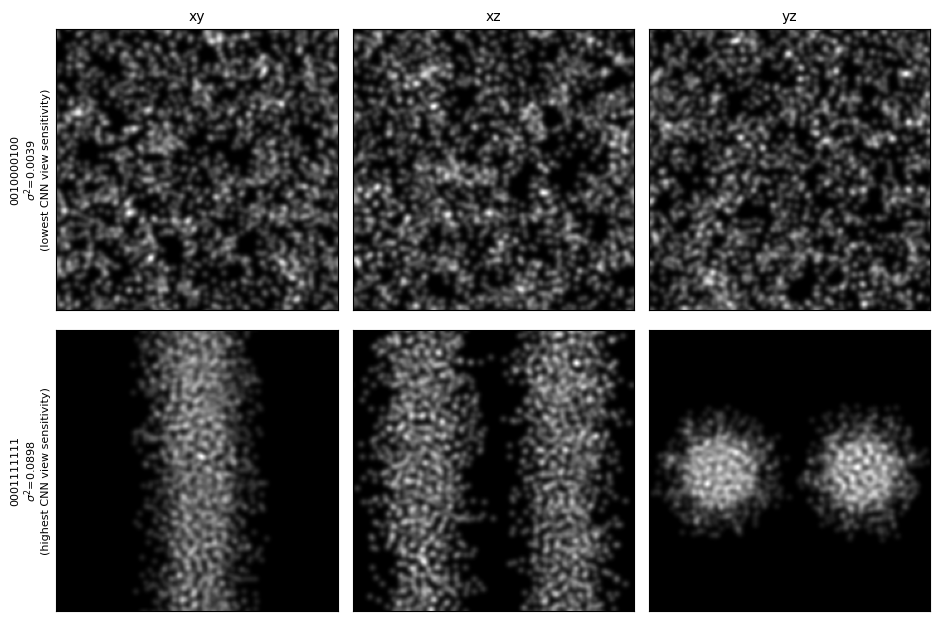

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(9.5, 6.4))
for row, (seq, spread, label) in enumerate([
        (lowest_seq,  view_spread.iloc[0]['view_spread'],  'lowest CNN view sensitivity'),
        (highest_seq, view_spread.iloc[-1]['view_spread'], 'highest CNN view sensitivity')]):
    for col, view in enumerate(['xy', 'xz', 'yz']):
        img_path = os.path.join(library_images_path, seq, f'all_{view}{name_extension}')
        ax = axes[row, col]
        if os.path.exists(img_path):
            ax.imshow(plt.imread(img_path), cmap='gray')
        else:
            # never fail silently: a blank panel would misread as "no structure"
            ax.text(0.5, 0.5, f'image missing:\n{seq} {view}', ha='center', va='center',
                    fontsize=8, transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(view, fontsize=10)
    axes[row, 0].set_ylabel(f'{seq}\n$\\sigma^2$={spread:.4f}\n({label})', fontsize=8)
fig.tight_layout()
plt.show()

The two sequences in the figure above differ in composition too, so "blocky vs. alternating" and "more B vs. less B" are tangled in that one comparison.
Let's isolate blockiness properly: restrict to sequences with the same B-fraction (the balanced, 5-A/5-B slice) and check whether `view_spread` still tracks blockiness (`longest_b_run`, `boundary_count`) within that fixed-composition group.

In [30]:
_boundary_count = lambda s: sum(1 for a, b in zip(s, s[1:]) if a != b)
_balanced = _vs[np.isclose(_vs['frac_B'], 0.5)].copy()
_balanced['boundary_count'] = [_boundary_count(s) for s in _balanced.index]
print(f'{len(_balanced)} balanced (5 A / 5 B) sequences in this library.')
r_lbr = np.corrcoef(_balanced['view_spread'], _balanced['longest_b_run'])[0, 1]
r_bnd = np.corrcoef(_balanced['view_spread'], _balanced['boundary_count'])[0, 1]
print(f'Within the fixed-composition (5A/5B) slice: '
      f'corr(view_spread, longest_b_run) = {r_lbr:+.3f}, '
      f'corr(view_spread, boundary_count) = {r_bnd:+.3f}')

126 balanced (5 A / 5 B) sequences in this library.
Within the fixed-composition (5A/5B) slice: corr(view_spread, longest_b_run) = +0.571, corr(view_spread, boundary_count) = -0.726


## [Check your understanding]: spread and morphology

* Look at the binary string of the highest-`view_spread` sequence above. Is it blocky (a few long runs of the same monomer) or alternating? Careful: that sequence also differs in composition from the lowest one. Read the fixed-composition-slice correlations just above for the architecture-only answer, not the two extrema alone.
* Predict before Section 2 runs: will sequences with high CNN view sensitivity tend to sit toward the **edge** or the **center** of the map? Commit to an answer now, you'll revisit it after Section 3.

> Within a fixed composition, blockier sequences (longer B-runs, fewer boundaries) do still tend toward higher `view_spread`.
> But the printed correlations above are real numbers, and they are noticeably weaker than the raw (composition-varying) correlations reported earlier in this section.
> The honest lesson: blockiness is a real, secondary contributor to `view_spread`, composition is still the dominant one.

## 2. Placing your sequence on the persisted map

### Fit once, transform forever

An embedding is a learned map.
NB04 fit a map $g: \mathbb{R}^{1280} \to \mathbb{R}^2$ from 64 reference fingerprints and persisted it: that trained object is now a fixed thing, `data/master64/pca.joblib`.
There are two library calls, and the difference between them is the whole lesson.

* `pca.fit(X)` / `pca.fit_transform(X)`: **learn** $g$ from `X` and place `X`'s points. NB04 called this exactly once, offline, building the deployed object.
* `pca.transform(X_new)`: push new points through the already-fixed $g$. New data lands on the existing axes without moving them.

This notebook only ever calls the second one.
The hazard has a name: leakage, or coordinate drift.
If the map were refit every time a new sequence arrived, each refit would produce a slightly rotated/flipped/rescaled frame, so the same physical structure would get different coordinates depending on who embedded it, and coordinates would stop being comparable across students.
The rule: the reference fit is frozen, everything new is transformed, never re-fit.
NB04 walks through the fit-vs-refit contrast directly, with the manual-SVD-vs-`sklearn.PCA` check that confirms the persisted object reproduces a from-scratch fit exactly.
We build on that result here rather than repeat it.

**Confidence check: pure `.transform()`, no `.fit()`.**
Before placing anything new, confirm that re-transforming the same 64 sequences the map was fit on reproduces the persisted `pca_coords.csv` exactly.
If this doesn't match, the deployed artifacts are out of sync and nothing downstream can be trusted.

In [31]:
import warnings

In [32]:
pca           = joblib.load(os.path.join(MASTER_DIR, 'pca.joblib'))
pca_coords_64 = pd.read_csv(os.path.join(MASTER_DIR, 'pca_coords.csv'), dtype={'Sequence': str})
pooled_64     = load_feature_csv(os.path.join(MASTER_DIR, 'pooled_features.csv'))

print(f'loaded pca ({pca.n_components_} components) and {len(pooled_64)} pooled feature rows')

loaded pca (5 components) and 64 pooled feature rows


In [33]:
z_cols     = [c for c in pca_coords_64.columns if c.startswith('z')]   # pca has n_components_ > 2
feats_64   = np.vstack(pooled_64['Feature'].values)
# `pca.transform` on this many rows (64) at once hits the same benign matmul RuntimeWarning as
# notebook 04's RidgeCV cells (sklearn 1.6.1 + Apple Accelerate BLAS quirk on n<=p-ish shapes,
# root-caused there; absent in newer sklearn). Filter only those 3 known messages, but verify
# immediately below rather than assume -- an actual mismatch here would still be caught.
with warnings.catch_warnings():
    for _msg in ('divide by zero encountered in matmul', 'overflow encountered in matmul',
                 'invalid value encountered in matmul'):
        warnings.filterwarnings('ignore', message=_msg, category=RuntimeWarning)
    z_64_check = pca.transform(feats_64)                               # .transform() ONLY
saved_64 = pca_coords_64.set_index('Sequence').loc[pooled_64['Sequence']][z_cols].values

print(f'checking {len(z_cols)} PCA columns against {len(saved_64)} saved coordinates')

checking 5 PCA columns against 64 saved coordinates


In [34]:
matches = np.allclose(z_64_check, saved_64, atol=1e-6)
print('transform() reproduces the persisted pca_coords.csv:', matches)
print('max abs difference:', np.max(np.abs(z_64_check - saved_64)))
assert matches, 'transform() does not reproduce the persisted map -- deployed artifacts out of sync'

transform() reproduces the persisted pca_coords.csv: True
max abs difference: 5.3290705182007514e-14


Now place a sequence the map has never seen.
Of the 528 canonical sequences in the full library, 64 were used to fit `pca`.
The other 464 are genuinely new relative to that fit: exactly the situation a freshly-simulated student sequence is in.
We make a deterministic, representative choice from that set using the measured replica-noise table below.

In [35]:
fitted_seqs = set(pca_coords_64['Sequence'])
candidates  = [s for s in library_seqs if s not in fitted_seqs]
print(f'{len(candidates)} of {len(library_seqs)} library sequences were NOT used to fit the PCA.')

# Pick, from the 464 non-fit candidates, the one whose measured 3-replica spread
# (data/master64/replica_noise.csv) sits closest to the population median -- so the
# live-vs-lookup discrepancy computed below lands near the expected replica-pair distance,
# not an arbitrary/unrepresentative one. Deterministic: no randomness in the pick itself.
_replica_noise = pd.read_csv(os.path.join(MASTER_DIR, 'replica_noise.csv'), dtype={'sequence': str})
_median_rmsd = float(_replica_noise['rmsd_centroid'].median())
_candidate_rmsd = _replica_noise.set_index('sequence').loc[candidates, 'rmsd_centroid']
new_seq = _candidate_rmsd.sub(_median_rmsd).abs().idxmin()
print(f'New sequence: {new_seq}  (not among the 64 the map was fit on; '
      f'rmsd_centroid={_candidate_rmsd[new_seq]:.3f}, population median={_median_rmsd:.3f})')

464 of 528 library sequences were NOT used to fit the PCA.
New sequence: 0011111100  (not among the 64 the map was fit on; rmsd_centroid=0.430, population median=0.432)


*Why re-extract a fingerprint when a corrected pooled one is already loaded?*

`library_df` was loaded above from `master_pooled_features_corrected.npz`, so its saved fingerprint is compatible with the deployed PCA and could be transformed directly.
The older `master_pooled_features.csv` file is the incompatible artifact: it was computed without ImageNet normalization and is deliberately never loaded here.
We nevertheless re-extract `new_seq` from its 9 stored images so you can see the complete deployment path and verify that it reproduces the corrected saved fingerprint.
That is fit-once/transform-forever discipline one level down: the featurizer is as much a part of the frozen pipeline as the PCA object is.

In [36]:
import torch
from PIL import Image
from torchvision import models, transforms

In [37]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(f'normalization: mean={IMAGENET_MEAN}, std={IMAGENET_STD}')

normalization: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]


In [38]:
def build_efficientnet_b0():
    """The exact featurizer the deployed PCA was fit on -- see campaign/build_master64.py."""
    torch.set_num_threads(1)
    weights = models.EfficientNet_B0_Weights.DEFAULT
    net = models.efficientnet_b0(weights=weights)
    net.classifier = torch.nn.Identity()
    net.eval()
    tf = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    return net, tf


net, tf = build_efficientnet_b0()

print(f'built EfficientNet-B0 feature extractor, image size {IMG_SIZE}')

built EfficientNet-B0 feature extractor, image size 224


In [39]:
new_image_paths = [
    os.path.join(library_images_path, new_seq, f'{ch}_{view}{name_extension}')
    for ch in ('A', 'B', 'all') for view in ('xy', 'xz', 'yz')
]
assert all(os.path.exists(p) for p in new_image_paths), 'missing a rendered image for new_seq'

print(f'found {len(new_image_paths)} rendered images for {new_seq}')

found 9 rendered images for 0011111100


In [40]:
with torch.no_grad():
    imgs = torch.stack([tf(Image.open(p)) for p in new_image_paths], dim=0)
    new_9_feats = net(imgs).numpy()          # (9, 1280): the 9 real per-view/channel fingerprints

print(f'new_9_feats shape: {new_9_feats.shape}')

new_9_feats shape: (9, 1280)


In [41]:
new_feature = new_9_feats.mean(axis=0)        # mean-pool -> the schema pca.transform() expects
z_new       = pca.transform(new_feature.reshape(1, -1))[0]
saved_new_feature = library_df.loc[library_df['Sequence'] == new_seq, 'Feature'].iloc[0]
fresh_matches_saved = np.allclose(new_feature, saved_new_feature, atol=1e-5)

print(f'pooled feature shape: {new_feature.shape}')
print('fresh extraction reproduces the corrected saved fingerprint:', fresh_matches_saved)
assert fresh_matches_saved, 'fresh fingerprint does not match the corrected saved feature'

pooled feature shape: (1280,)
fresh extraction reproduces the corrected saved fingerprint: True


In [42]:
print(f'transform() places {new_seq} at z = ({z_new[0]:.3f}, {z_new[1]:.3f}) on the frozen axes.')

transform() places 0011111100 at z = (5.534, -2.231) on the frozen axes.


**What you should see:** the reproduction check above prints `True` with a max difference near machine precision (`~1e-15`), then `464 of 528 library sequences were NOT used to fit the PCA`, followed by the chosen sequence and, after a few seconds of CNN inference on 9 images, its `(z0, z1)` coordinate.

Choosing a 10-mer, 200-chain system means it is small enough to simulate live, right here, on Colab's CPU.
Everything above used a pre-rendered image of `new_seq` from the offline library build.
Let's instead actually simulate it, right now, with the exact production physics (`campaign/simulate.py::run_one`: 200 chains, FENE-WCA $k{=}30$, $r_0{=}1.5$, Langevin $k_BT{=}0.5$, $dt{=}0.005$, 24 frame-chunks of $\lfloor 125{,}000/24 \rfloor$ steps — 124,992 in total, chunked exactly as the production campaign chunks its own runs): the same config `sources/day1/02_virtual_lab.py` measured at about 45 seconds of CPU wall-clock.
This run's seed is drawn fresh, not fixed, so its result is a genuine new, independent replica of `new_seq`, the same way each of the dataset's own 3 seeds is.

In [43]:
import hoomd
import sys as _sys_live
_sys_live.path.insert(0, os.path.abspath('..'))
# `render_kde_images` come from the spliced campaign/featurize.py cell near the top.

NUM_CHAINS, TOTAL_STEPS, N_FRAMES = 200, 125_000, 24
_live_seed = int(np.random.default_rng().integers(0, 2**16))

print(f'live simulation of {new_seq}: {NUM_CHAINS} chains, seed={_live_seed}')

live simulation of 0011111100: 200 chains, seed=12389


In [44]:
frame = build_frame(new_seq, num_chains=NUM_CHAINS)
hoomd_device = hoomd.device.CPU()
sim = hoomd.Simulation(device=hoomd_device, seed=_live_seed)
sim.create_state_from_snapshot(frame)

In [45]:
nl = hoomd.md.nlist.Cell(buffer=0.4)
lj = hoomd.md.pair.LJ(nlist=nl, default_r_cut=2.5)
for pair in [('A', 'A'), ('A', 'B'), ('B', 'B')]:
    lj.params[pair] = dict(epsilon=1.0, sigma=1.0)
lj.r_cut[('A', 'A')] = 2 ** (1 / 6)
lj.r_cut[('A', 'B')] = 2 ** (1 / 6)
lj.mode = 'shift'

print('LJ pair potential configured for A-A, A-B, B-B; WCA cutoff on A-A/A-B')

LJ pair potential configured for A-A, A-B, B-B; WCA cutoff on A-A/A-B


In [46]:
fenewca = hoomd.md.bond.FENEWCA()
fenewca.params['bond'] = dict(k=30.0, r0=1.5, epsilon=1.0, sigma=1.0, delta=0.0)

sim.state.thermalize_particle_momenta(filter=hoomd.filter.All(), kT=0.5)
langevin = hoomd.md.methods.Langevin(filter=hoomd.filter.All(), kT=0.5)
sim.operations.integrator = hoomd.md.Integrator(dt=0.005, methods=[langevin], forces=[lj, fenewca])

print('integrator: dt=0.005, Langevin kT=0.5, FENE-WCA bonds (k=30, r0=1.5)')

integrator: dt=0.005, Langevin kT=0.5, FENE-WCA bonds (k=30, r0=1.5)


Live simulation of 0011111100 finished: 25 frames, 124992 total steps, seed=12389.


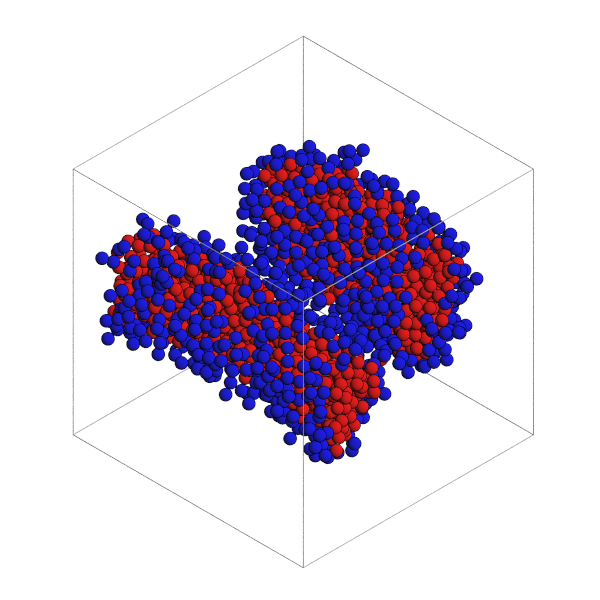

In [47]:
chunk = max(1, TOTAL_STEPS // N_FRAMES)
live_traj = Trajectory(sequence=new_seq, num_chains=NUM_CHAINS)
live_traj.frames.append(grab_frame(sim.state.get_snapshot()))
live_traj.times.append(sim.timestep)
for _ in range(N_FRAMES):
    sim.run(chunk)
    live_traj.frames.append(grab_frame(sim.state.get_snapshot()))
    live_traj.times.append(sim.timestep)
print(f'Live simulation of {new_seq} finished: {len(live_traj.frames)} frames, '
      f'{sim.timestep} total steps, seed={_live_seed}.')
render_pretty(live_traj)

In [48]:
live_out_dir = os.path.join('_live_images', new_seq)
live_image_paths = render_kde_images(live_traj, live_out_dir, kde_sigma=2.0, img_size=IMG_SIZE)
with torch.no_grad():
    live_imgs = torch.stack([tf(Image.open(p)) for p in live_image_paths], dim=0)
    live_9_feats = net(live_imgs).numpy()
live_feature = live_9_feats.mean(axis=0)
z_new_live = pca.transform(live_feature.reshape(1, -1))[0]

print(f'live run z = ({z_new_live[0]:+.3f}, {z_new_live[1]:+.3f})')

live run z = (+5.861, -1.391)


In [49]:
_pair_dists = np.concatenate([
    np.linalg.norm(_replica_noise[['z0_seed1', 'z1_seed1']].values
                    - _replica_noise[['z0_seed2', 'z1_seed2']].values, axis=1),
    np.linalg.norm(_replica_noise[['z0_seed1', 'z1_seed1']].values
                    - _replica_noise[['z0_seed3', 'z1_seed3']].values, axis=1),
    np.linalg.norm(_replica_noise[['z0_seed2', 'z1_seed2']].values
                    - _replica_noise[['z0_seed3', 'z1_seed3']].values, axis=1),
])
_live_vs_lookup = float(np.linalg.norm(z_new_live - z_new))
_pct = float(np.mean(_pair_dists <= _live_vs_lookup)) * 100
_lookup_seed1 = _replica_noise.loc[
    _replica_noise['sequence'] == new_seq, ['z0_seed1', 'z1_seed1']
].values[0]
_lookup_is_seed1 = np.allclose(z_new[:2], _lookup_seed1, atol=1e-5)

print(f'{len(_pair_dists)} replica-pair distances measured; median {np.median(_pair_dists):.3f}')
print('deployed lookup matches replica_noise.csv seed 1:', _lookup_is_seed1)
assert _lookup_is_seed1, 'deployed lookup no longer matches the documented seed-1 replica'

1584 replica-pair distances measured; median 0.649
deployed lookup matches replica_noise.csv seed 1: True


In [50]:
def _ordinal(n):
    n = int(round(n))
    s = ('th' if 11 <= n % 100 <= 13
         else {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th'))
    return f'{n}{s}'

_p90 = float(np.percentile(_pair_dists, 90))
print(f'z_new (deployed lookup coordinate) : ({z_new[0]:+.3f}, {z_new[1]:+.3f})')
print(f'z_new_live (this fresh run)         : ({z_new_live[0]:+.3f}, {z_new_live[1]:+.3f})')
print(f'|difference|                        : {_live_vs_lookup:.4f}')
print(f'That places this live run at the {_ordinal(_pct)} percentile of the 1,584 real '
      f'same-sequence replica-pair distances measured in data/master64/replica_noise.csv '
      f'(median {np.median(_pair_dists):.3f}, p90 {_p90:.3f}).')
if _pct <= 90:
    print('This is well within the expected range -- a successful replication.')
else:
    print(f'That is above p90, meaning this particular random seed produced an unusually '
          f'large discrepancy. This can happen: ~10% of replica pairs land above p90 by '
          f'definition. One tail draw does not by itself establish that the pipeline is broken; '
          f'it is a reason to inspect another replica and the diagnostics below.')

z_new (deployed lookup coordinate) : (+5.534, -2.231)
z_new_live (this fresh run)         : (+5.861, -1.391)
|difference|                        : 1.6410
That places this live run at the 94th percentile of the 1,584 real same-sequence replica-pair distances measured in data/master64/replica_noise.csv (median 0.649, p90 1.457).
That is above p90, meaning this particular random seed produced an unusually large discrepancy. This can happen: ~10% of replica pairs land above p90 by definition. One tail draw does not by itself establish that the pipeline is broken; it is a reason to inspect another replica and the diagnostics below.


`z_new` is one replica: the deployed seed-1 lookup, the single replica convention the whole course uses.
(One bookkeeping wrinkle, documented in `data/master64/REPLICA_NOISE_NOTE.md`: the deployed table's columns are *labelled* seed 1, but the pre-rendered images behind them match the GSD bundle's `_seed3.gsd` files — notebook 06 byte-checks that correspondence. Either way it is the same single-replica convention.)
`z_new_live` is another, independent replica of the same physical sequence, projected through the same frozen PCA.
They are not supposed to match exactly.
MD is stochastic, and `data/master64/replica_noise.csv` already measured how much two independent replicas of the same sequence typically disagree.
If this live run's discrepancy sits near the median of that distribution, that is a straightforward successful replication.
If it lands above p90, it is an unusually large draw from the measured replica distribution.
One tail draw does not establish a broken pipeline, but it should trigger the scientific response:
inspect another replica and the diagnostics below rather than explaining the discrepancy away.

### [Optional] Pooling over time: does z drift within one trajectory?

**[Optional, deeper rigor: skip on a first pass]** This cell re-featurizes every frame of one real trajectory live.
It costs extra compute and needs a local GSD file to run at all.
Skip it and you'll miss seeing equilibration happen directly in the embedding, but nothing later in the notebook depends on it.

The view-spread analysis above pools over camera angle at a single, final, equilibrated frame, and the live-vs-lookup comparison you just ran did too: one $z$ per replica, taken from its last frame.
There is a second, temporal kind of spread this notebook has never shown: project every saved frame of one real trajectory through the same featurize to CNN to persisted-PCA pipeline and watch $z(t)$ move as the simulation runs.
Early frames are closer to the random initial lattice packing, later frames are closer to equilibrium: this is the same equilibration idea notebook 03 introduced, now seen directly in the embedding.

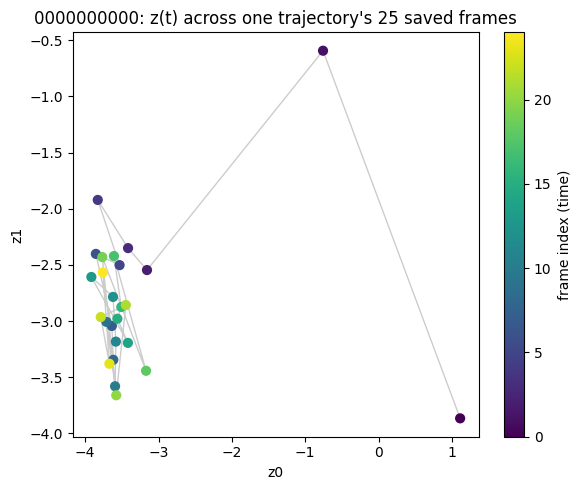

Per-frame spread (RMS distance from the 25-frame mean): 1.499 Z-units


In [51]:
import sys as _sys_zt
_sys_zt.path.insert(0, os.path.abspath('..'))
# `render_kde_images` come from the spliced campaign/featurize.py cell near the top.

_zt_seq = library_seqs[0]
_zt_gsd_path = os.path.join('..', 'data', 'kg10-gsd-bundle', 'gsd', f'{_zt_seq}_seed1.gsd')
# load_gsd/Trajectory/grab_frame come from the spliced day2/cdse_lab.py above -- no module
# prefix, since CDSE-INCLUDE splices that file's literal source into this notebook.
_zt_traj = load_gsd(_zt_gsd_path) if os.path.exists(_zt_gsd_path) else None

if _zt_traj is not None:
    _zt_out_root = os.path.join('_zt_images', _zt_seq)
    _zt_z = []
    for _fi in range(len(_zt_traj.frames)):
        _zt_paths = render_kde_images(_zt_traj, os.path.join(_zt_out_root, str(_fi)),
                                       kde_sigma=2.0, img_size=IMG_SIZE, frame_idx=_fi)
        with torch.no_grad():
            _zt_imgs = torch.stack([tf(Image.open(p)) for p in _zt_paths], dim=0)
            _zt_feat = net(_zt_imgs).numpy().mean(axis=0)
        _zt_z.append(pca.transform(_zt_feat.reshape(1, -1))[0])
    _zt_z = np.array(_zt_z)

    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(_zt_z[:, 0], _zt_z[:, 1], c=np.arange(len(_zt_z)), cmap='viridis', s=40)
    ax.plot(_zt_z[:, 0], _zt_z[:, 1], color='grey', alpha=0.4, linewidth=1, zorder=0)
    cb = plt.colorbar(sc, ax=ax); cb.set_label('frame index (time)')
    ax.set_xlabel('z0'); ax.set_ylabel('z1')
    ax.set_title(f'{_zt_seq}: z(t) across one trajectory\'s {len(_zt_z)} saved frames')
    plt.tight_layout()
    plt.show()
    print(f'Per-frame spread (RMS distance from the {len(_zt_z)}-frame mean): '
          f'{float(np.sqrt(np.mean(np.sum((_zt_z - _zt_z.mean(axis=0)) ** 2, axis=1)))):.3f} Z-units')
else:
    print(f'(No local GSD for {_zt_seq} -- skipping the within-trajectory z(t) demo; '
          'this is optional, not load-bearing for the rest of the notebook.)')

Read the color gradient, not just the scatter.
If early (dark) frames sit off to one side and late (bright) frames cluster tightly together, that is equilibration happening in the embedding itself.
That's exactly why the deployed pipeline uses the final, equilibrated frame rather than pooling every frame a trajectory ever visited.

## 3. Where did your sequence land?

Plot the persisted 64-point map, the frozen frame, with the new sequence's transformed coordinate highlighted in red.
Think about:

* **Location**: which region of the map is the new sequence closest to?
* **Density**: does it land inside a cluster of the 64 reference points, or off on its own?
* **Chemistry**: how does its position track its block ratio or A/B balance?

In the larger length-20+ manifolds of Statt et al. (2021), named morphological archetypes (strings, membranes, vesicles, liquid droplets, structured liquids and several micelle types) sat at the periphery of the map, with continuous blends filling the interior.
Those archetype labels are learnable straight from sequence, too: Bhattacharya et al. (2022) trained recurrent networks to predict them, the supervised complement of the unsupervised map built here, and the direct ancestor of the notebook 06 surrogate.

A 64-point length-10 map is much smaller and may not reproduce that global geometry.
Treat "edge = clean archetype, center = blend" as a hypothesis to check against your own map, not a guarantee.

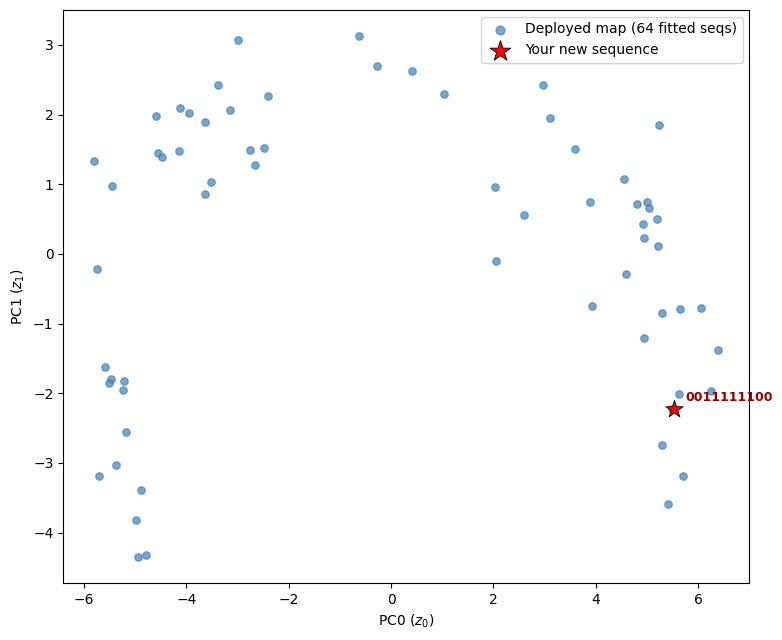

In [52]:
fig, ax = plt.subplots(figsize=(8, 6.5))

ax.scatter(pca_coords_64['z0'], pca_coords_64['z1'],
           s=28, alpha=0.7, color='steelblue', label=f'Deployed map (64 fitted seqs)')
ax.scatter(z_new[0], z_new[1],
           s=170, color='red', zorder=5, marker='*', edgecolors='black', linewidths=0.6,
           label='Your new sequence')
ax.annotate(new_seq, (z_new[0], z_new[1]), textcoords='offset points', xytext=(8, 6),
            fontsize=9, color='darkred', weight='bold')

ax.set_xlabel('PC0 ($z_0$)')
ax.set_ylabel('PC1 ($z_1$)')
ax.legend(markerscale=1.2, loc='best')
plt.tight_layout()
plt.show()

**What you should see:** the same 64-point cloud NB04 rendered, with one red star placed by `.transform()`, not refit, not re-derived, just pushed through the existing axes.

Now revisit your Exercise 1 prediction.
Did the high-`view_spread` sequences you inspected land near the edge of this map, or the center?
There's no answer key here, form your own read.

### Who are your latent neighbors?

The 64-point deployed map is sparse: useful for placement, too small to search for neighbors in usefully.
`data/master64/sequence_z_targets.csv` fixes that: it is the same frozen PCA, `.transform()`-ed offline across all 528 canonical sequences (the table notebook 06 trains its surrogate against).
Load it, confirm it agrees with the `z_new` you just computed by hand, then search it for the new sequence's latent neighbors.

In [53]:
from sklearn.neighbors import NearestNeighbors

In [54]:
z_targets = pd.read_csv(os.path.join(MASTER_DIR, 'sequence_z_targets.csv'), dtype={'Sequence': str})

print(f'loaded {len(z_targets)} sequence_z_targets rows')

loaded 528 sequence_z_targets rows


In [55]:
z_shipped = z_targets.loc[z_targets['Sequence'] == new_seq, ['z0', 'z1']].values[0]
print('Matches the shipped sequence_z_targets.csv row:',
      np.allclose(z_new[:2], z_shipped, atol=1e-5))     # z_targets.csv keeps only the first 2 PCs

# Search the full 528-point transformed library for the new sequence's nearest neighbors.
targets_coords = z_targets[['z0', 'z1']].values
nn  = NearestNeighbors(n_neighbors=6).fit(targets_coords)
new_idx = z_targets.index[z_targets['Sequence'] == new_seq][0]
dists, idxs = nn.kneighbors(targets_coords[[new_idx]])

Matches the shipped sequence_z_targets.csv row: True


In [56]:
print(f'\nLatent neighbors of {new_seq}:')
shown = 0
for d, j in zip(dists[0], idxs[0]):
    if z_targets.iloc[j]['Sequence'] == new_seq:
        continue
    print(f"    {z_targets.iloc[j]['Sequence']}   d = {d:.3f}")
    shown += 1
    if shown == 5:
        break


Latent neighbors of 0011111100:
    1110010111   d = 0.045
    1011101111   d = 0.073
    1011110111   d = 0.157
    1010011111   d = 0.172
    0011111011   d = 0.178


Read the neighbor strings against the query.
Do they share where the B-blocks sit, and how long the runs are?

If the nearest sequences are all blocky in the same way, even when their exact monomer patterns differ, the CNN to PCA map has learned that **block architecture, not just composition, drives structure**.

That regularity is exactly what the surrogate in notebook 06 exploits: it can predict $z$ from a sequence only because nearby sequences genuinely land nearby.
One caveat carried over from notebook 04: keep to the rank of near neighbors, "these five are closest," rather than trusting absolute distance values as a global metric.

## [Check your understanding]: neighbors and chemistry

* List your new sequence's top-3 latent neighbors and count how many monomers differ from each (the **Hamming distance**, the number of mismatched positions).
* Predict: are near-latent-neighbors also near in sequence space (only a few flips apart), or can very different strings map to the same structure?
* Relate your answer to the many-to-one nature of the sequence-to-structure map, a preview of why inverse design in Day 3 is ill-posed (many sequences can hit the same target).

> Different strings landing on the same spot is degeneracy. It's exactly what makes inverse design hard, and interesting.

## 4. Handing off to notebook 06

Notebook 06 trains a sequence-to-$z$ surrogate.
It does not re-run any of this notebook's feature extraction or PCA transform: it loads `data/master64/sequence_z_targets.csv` directly, the exact 528-row `Sequence, z0, z1` table you just cross-checked above.

That file was built once, offline, by transforming every canonical sequence's pooled fingerprint through this same persisted `pca.joblib`: the identical discipline this notebook just walked through by hand, at library scale.

Notebook 06 also owns its own train/validation/test split, with the reversal-symmetry and leakage discipline that a 528-sequence, many-duplicate-free table requires. That's its job, not this notebook's.
Your job here was placement and interpretation: given a persisted map and a sequence it has never seen, land it correctly and read what its neighborhood says.

In [57]:
print(z_targets.head())
print(f'\n{len(z_targets)} rows. This is exactly what notebook 06 loads.')

     Sequence        z0        z1
0  0000000000 -3.758736 -2.566577
1  0000000001 -4.896034 -3.388658
2  0000000010 -4.938156 -4.355247
3  0000000011 -3.149205  0.421254
4  0000000100 -4.989589 -3.826033

528 rows. This is exactly what notebook 06 loads.


## References

- Statt, A.; Kleeblatt, D. C.; Reinhart, W. F. Unsupervised learning of sequence-specific aggregation behavior for a model copolymer. *Soft Matter* **2021**, *17*, 7697-7707. https://doi.org/10.1039/d1sm01012c
- Bhattacharya, D.; Kleeblatt, D. C.; Statt, A.; Reinhart, W. F. Predicting aggregate morphology of sequence-defined macromolecules with recurrent neural networks. *Soft Matter* **2022**, *18*, 5037-5051. https://doi.org/10.1039/d2sm00452f
- Curtis, K. A.; Statt, A.; Reinhart, W. F. Predicting self-assembly of sequence-controlled copolymers with stochastic sequence variation. *Soft Matter* **2025**, *21*, 2143-2151. https://doi.org/10.1039/d4sm01219d
- McInnes, L.; Healy, J.; Melville, J. UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction. *arXiv:1802.03426*, **2018**. (Statt et al.'s original two-stage embedding. This workshop deploys a single-stage PCA instead: simpler to persist and `.transform()` reproducibly for a whole cohort. Notebook 04 compares the two directly.)